# 📊 Análisis del Impacto del Fenómeno del Niño en el Precio de Bolsa de Energía Eléctrica en Colombia

**Proyecto Final — Bootcamp TIC Talento Tech 2026**
**Equipo:** Jordan Rincón · Julián Mejía · Tulio Ruiz
**Fuentes:** XM Sinergox · Banco de la República · World Bank · NOAA · UPME

---

## Estructura del Notebook

1. **Configuración** — Librerías y estilo visual
2. **Carga de datos** — Lectura del Excel principal
3. **Limpieza y verificación** — Nulos, estadísticas, validación
4. **Ingeniería de variables** — Features derivadas y rezagos
5. **Integración de fuentes adicionales** — FNCER y embalses regionales
6. **Análisis Exploratorio de Datos (EDA)** — 5 visualizaciones clave
7. **Matriz de correlaciones**
8. **Análisis cuantitativos**
   - 8.1 Elasticidad del precio al ONI
   - 8.2 Vulnerabilidad regional
   - 8.3 Simulación de mitigación FNCER
9. **Exportación a base de datos SQL**
10. **Resumen ejecutivo**


## 1. ⚙️ Configuración

Importa todas las librerías necesarias y define el estilo visual del notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Configuración visual — tema oscuro
plt.rcParams.update({
    'figure.facecolor': '#0F1B2D',
    'axes.facecolor':   '#1A2B45',
    'axes.edgecolor':   '#2E4A6A',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2E4A6A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# Paleta de colores del proyecto
COLORES = {
    'bolsa'   : '#FF6B6B',
    'hidro'   : '#3A8DFF',
    'reserva' : '#00C896',
    'fosil'   : '#FFB347',
    'oni'     : '#C77DFF',
    'demanda' : '#48DBFB',
    'trm'     : '#FF9F43',
    'nino'    : '#FF6B6B',
    'nina'    : '#3A8DFF',
    'neutro'  : '#A0B4CC',
}
CARD_BG = '#1A2B45'

print('✅ Librerías cargadas y estilo configurado')

✅ Librerías cargadas y estilo configurado


## 2. 📥 Carga de Datos

Lee el archivo principal `Variables V2.xlsx` con 312 observaciones mensuales (enero 2000 – diciembre 2025).

In [ ]:
# Carga del archivo Excel principal
df_raw = pd.read_excel('/content/Variables V2.xlsx', sheet_name='Hoja1', header=2)

# Renombrar columnas a nombres cortos y consistentes
df_raw.columns = [
    'fecha', 'gen_hidro_gwh', 'gen_fosil_gwh',
    'disp_hidro', 'disp_termica',
    'reserva_decimal', 'cap_util_gwh', 'vol_util_gwh',
    'demanda_gwh', 'trm',
    'precio_carbon_usd', 'precio_gas_usd',
    'oferta_carbon_cop', 'oferta_gas_cop',
    'oni', 'precio_bolsa_cop'
] + [f'_drop{i}' for i in range(df_raw.shape[1] - 16)]

# Mantener solo columnas útiles
cols_utiles = ['fecha','gen_hidro_gwh','gen_fosil_gwh','disp_hidro','disp_termica',
               'reserva_decimal','cap_util_gwh','vol_util_gwh','demanda_gwh','trm',
               'precio_carbon_usd','precio_gas_usd','oferta_carbon_cop',
               'oferta_gas_cop','oni','precio_bolsa_cop']
df_raw = df_raw[cols_utiles]

# Filtrar solo filas con fechas válidas y ordenar
df_raw = df_raw[pd.to_datetime(df_raw['fecha'], errors='coerce').notna()].copy()
df_raw['fecha'] = pd.to_datetime(df_raw['fecha'])
df_raw = df_raw.sort_values('fecha').reset_index(drop=True)

print(f'✅ Datos cargados: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print(f'📅 Período: {df_raw.fecha.min().strftime("%b %Y")} → {df_raw.fecha.max().strftime("%b %Y")}')

✅ Datos cargados: 312 filas × 16 columnas
📅 Período: Jan 2000 → Dec 2025


## 3. 🧹 Limpieza y Verificación de Calidad

Verifica nulos, estadísticas descriptivas y rangos esperados antes de continuar con el análisis.

In [ ]:
# ── Verificar nulos por columna ──────────────────────────────────
print('=== NULOS POR COLUMNA ===')
for col in df_raw.columns[1:]:
    n = df_raw[col].isna().sum()
    status = '✅' if n == 0 else f'⚠️  {n} nulos'
    print(f'  {status}  {col}')

=== NULOS POR COLUMNA ===
  ✅  gen_hidro_gwh
  ✅  gen_fosil_gwh
  ✅  disp_hidro
  ✅  disp_termica
  ✅  reserva_decimal
  ✅  cap_util_gwh
  ✅  vol_util_gwh
  ✅  demanda_gwh
  ✅  trm
  ✅  precio_carbon_usd
  ✅  precio_gas_usd
  ✅  oferta_carbon_cop
  ✅  oferta_gas_cop
  ✅  oni
  ✅  precio_bolsa_cop


In [ ]:
# ── Estadísticas descriptivas ────────────────────────────────────
df_raw.describe().round(2)

,fecha,gen_hidro_gwh,gen_fosil_gwh,disp_hidro,disp_termica,reserva_decimal,cap_util_gwh,vol_util_gwh,demanda_gwh,trm,precio_carbon_usd,precio_gas_usd,oferta_carbon_cop,oferta_gas_cop,oni,precio_bolsa_cop
count,312,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00,312.00
mean,2012-12-15 17:23:04.615384576,3950.97,1105.28,0.82,0.83,0.68,15823.37,10683.36,4976.52,2762.45,85.75,4.31,177.03,408.35,-0.01,182.64
min,2000-01-01 00:00:00,2097.93,355.64,0.62,0.49,0.31,5342.21,2738.08,3193.07,1712.28,21.75,1.50,65.41,107.54,-1.70,35.65
25%,2006-06-23 12:00:00,3373.50,752.92,0.79,0.79,0.58,15131.19,9216.37,4139.96,2035.93,52.23,2.79,125.23,256.12,-0.60,72.62
50%,2012-12-16 12:00:00,3855.91,918.57,0.82,0.83,0.69,15428.40,10920.89,4916.61,2536.22,75.49,3.73,156.13,331.96,-0.10,113.88
75%,2019-06-08 12:00:00,4554.10,1358.59,0.86,0.88,0.79,16986.96,12410.68,5769.04,3312.21,107.50,5.38,205.47,477.18,0.50,194.23
max,2025-12-01 00:00:00,6060.77,3183.88,0.93,0.97,0.91,18231.90,15412.61,7151.88,4926.66,340.79,13.52,615.78,1162.55,2.80,1554.23
std,NaN,881.80,514.01,0.05,0.07,0.13,1641.68,2306.36,1034.96,821.57,55.55,2.15,75.04,231.06,0.81,196.05


In [ ]:
# ── Verificar que la reserva esté en formato decimal (0-1) ───────
print(f'Reserva mínima: {df_raw.reserva_decimal.min():.4f}  ({df_raw.reserva_decimal.min()*100:.1f}%)')
print(f'Reserva máxima: {df_raw.reserva_decimal.max():.4f}  ({df_raw.reserva_decimal.max()*100:.1f}%)')
print(f'Reserva media:  {df_raw.reserva_decimal.mean():.4f}  ({df_raw.reserva_decimal.mean()*100:.1f}%)')

Reserva mínima: 0.3111  (31.1%)
Reserva máxima: 0.9073  (90.7%)
Reserva media:  0.6754  (67.5%)


## 4. 🔧 Ingeniería de Variables

Crea las variables derivadas necesarias para el análisis:
- **`reserva_pct`** — reserva expresada como porcentaje (más legible)
- **`part_hidro_pct`** — participación hidráulica en la generación total
- **`costo_termico_cop`** — costo combinado de carbón en pesos (carbón USD × TRM)
- **`evento_climatico`** — clasificación según umbrales ONI ± 0.5
- **Rezagos** — `reserva_lag1`, `reserva_lag2`, `oni_lag1` para análisis temporal

In [ ]:
df = df_raw.copy()

# 1. Reserva en porcentaje (legible)
df['reserva_pct'] = df['reserva_decimal'] * 100

# 2. Participación hidráulica en la generación total
df['part_hidro_pct'] = (df['gen_hidro_gwh'] /
                        (df['gen_hidro_gwh'] + df['gen_fosil_gwh'])) * 100

# 3. Costo térmico efectivo en COP (carbón × TRM)
df['costo_termico_cop'] = df['precio_carbon_usd'] * df['trm']

# 4. Clasificación del evento climático ONI
df['evento_climatico'] = 'neutro'
df.loc[df['oni'] >= 0.5,  'evento_climatico'] = 'nino'
df.loc[df['oni'] <= -0.5, 'evento_climatico'] = 'nina'

# 5. Rezagos — la reserva de hoy afecta el precio del próximo mes
df['reserva_lag1'] = df['reserva_pct'].shift(1)
df['reserva_lag2'] = df['reserva_pct'].shift(2)
df['oni_lag1']     = df['oni'].shift(1)

# 6. Variables temporales
df['anio']     = df['fecha'].dt.year
df['mes']      = df['fecha'].dt.month
df['semestre'] = df['fecha'].dt.month.apply(lambda m: 1 if m <= 6 else 2)

# 7. Eliminar columna redundante (reserva_decimal ya está en reserva_pct)
df.drop(columns=['reserva_decimal'], inplace=True)

# DataFrame para análisis con rezagos (sin NaN)
df_modelo = df.dropna().reset_index(drop=True)

print(f'✅ Dataset principal     : {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'✅ Dataset para modelado : {df_modelo.shape[0]} filas (sin NaN en rezagos)')
print()
print('Variables del dataset:')
for c in df.columns:
    print(f'  • {c}')

✅ Dataset principal     : 312 filas × 25 columnas
✅ Dataset para modelado : 310 filas (sin NaN en rezagos)

Variables del dataset:
  • fecha
  • gen_hidro_gwh
  • gen_fosil_gwh
  • disp_hidro
  • disp_termica
  • cap_util_gwh
  • vol_util_gwh
  • demanda_gwh
  • trm
  • precio_carbon_usd
  • precio_gas_usd
  • oferta_carbon_cop
  • oferta_gas_cop
  • oni
  • precio_bolsa_cop
  • reserva_pct
  • part_hidro_pct
  • costo_termico_cop
  • evento_climatico
  • reserva_lag1
  • reserva_lag2
  • oni_lag1
  • anio
  • mes
  • semestre


## 5. 🔗 Integración de Fuentes Adicionales

Incorpora dos datasets complementarios al dataset principal:
- **5.1 FNCER (UPME)** — 158 proyectos renovables, 6,000 MW totales
- **5.2 Embalses regionales (XM)** — niveles diarios por las 5 regiones del SIN

### 5.1 Integración FNCER — Capacidad Solar y Eólica Acumulada

In [ ]:
# ── Cargar archivo FNCER ─────────────────────────────────────────
fncer_raw = pd.read_excel('/content/Meta_FNCER.xlsx', sheet_name='Data')
fncer_raw.columns = [
    'proyecto','tipo','capacidad_mw','departamento','municipio',
    'cod_depto','cod_muni','fecha_fpo','energia_kwh_dia',
    'usuarios','inversion_cop','empleos','co2_ton_año'
]

# Limpiar fechas — eliminar proyectos futuros (fecha > 2026-05)
fncer_raw['fecha_fpo'] = pd.to_datetime(fncer_raw['fecha_fpo'], errors='coerce')
fncer_op = fncer_raw[fncer_raw['fecha_fpo'] <= '2026-05-31'].copy()

print(f'Total proyectos en archivo : {len(fncer_raw)}')
print(f'Proyectos ya operativos    : {len(fncer_op)}')
print(f'Proyectos futuros excluidos: {len(fncer_raw) - len(fncer_op)}')
print()
print('Capacidad operativa por tipo:')
print(fncer_op.groupby('tipo')['capacidad_mw'].agg(['sum','count'])
      .rename(columns={'sum':'MW total','count':'Proyectos'}))

# ── Crear serie de tiempo mensual de capacidad acumulada ─────────
fncer_op['fecha_mes'] = fncer_op['fecha_fpo'].dt.to_period('M').dt.to_timestamp()
por_mes = (fncer_op.groupby(['fecha_mes','tipo'])['capacidad_mw']
           .sum().unstack(fill_value=0).reset_index())

# Asegurar que existan ambas columnas
if 'Solar'  not in por_mes.columns: por_mes['Solar']  = 0
if 'Eólico' not in por_mes.columns: por_mes['Eólico'] = 0
por_mes.rename(columns={'Solar':'solar_mw_nuevo',
                         'Eólico':'eolico_mw_nuevo'}, inplace=True)

# Expandir al rango completo 2000–2025
rango_fechas = pd.date_range('2000-01-01', '2025-12-01', freq='MS')
por_mes_full = (por_mes.set_index('fecha_mes')
                .reindex(rango_fechas, fill_value=0)
                .reset_index().rename(columns={'index':'fecha'}))

# Capacidad ACUMULADA mes a mes
por_mes_full['cap_solar_acum_mw']  = por_mes_full['solar_mw_nuevo'].cumsum()
por_mes_full['cap_eolica_acum_mw'] = por_mes_full['eolico_mw_nuevo'].cumsum()
por_mes_full['cap_fncer_total_mw'] = (por_mes_full['cap_solar_acum_mw'] +
                                       por_mes_full['cap_eolica_acum_mw'])

# ── Empalmar con dataset principal ───────────────────────────────
df['fecha'] = pd.to_datetime(df['fecha'])
por_mes_full['fecha'] = pd.to_datetime(por_mes_full['fecha'])

df = df.merge(
    por_mes_full[['fecha','cap_solar_acum_mw','cap_eolica_acum_mw','cap_fncer_total_mw']],
    on='fecha', how='left'
)
df[['cap_solar_acum_mw','cap_eolica_acum_mw','cap_fncer_total_mw']] = \
    df[['cap_solar_acum_mw','cap_eolica_acum_mw','cap_fncer_total_mw']].fillna(0)

# Variable derivada — penetración FNCER
df['penetracion_fncer_pct'] = (df['cap_fncer_total_mw'] /
                                (df['cap_fncer_total_mw'] + 18000)) * 100

# Tabla resumen por departamento
mapa_depto = (fncer_op.groupby('departamento')
              .agg(proyectos=('proyecto','count'),
                   capacidad_mw=('capacidad_mw','sum'),
                   usuarios=('usuarios','sum'),
                   empleos=('empleos','sum'),
                   co2_evitado=('co2_ton_año','sum'))
              .reset_index()
              .sort_values('capacidad_mw', ascending=False))

print()
print('✅ FNCER integrado al dataset principal')
print()
print('🗺️  Top 5 departamentos por capacidad FNCER:')
print(mapa_depto[['departamento','proyectos','capacidad_mw','usuarios']].head(5).to_string(index=False))

Total proyectos en archivo : 158
Proyectos ya operativos    : 155
Proyectos futuros excluidos: 3

Capacidad operativa por tipo:
        MW total  Proyectos
tipo                       
Eólico   1615.17         13
Solar    4070.35        142

✅ FNCER integrado al dataset principal

🗺️  Top 5 departamentos por capacidad FNCER:
departamento  proyectos  capacidad_mw  usuarios
  LA GUAJIRA         12       1605.27   2672358
   ATLÁNTICO         15        829.74    690649
   SANTANDER          5        788.54    656357
      TOLIMA         14        449.81    374406
       CESAR          5        371.90    309559


### 5.2 Integración Embalses Regionales (datos diarios → mensuales)

In [ ]:
# ── Cargar datos diarios de embalse por región ──────────────────
emb_raw = pd.read_excel('/content/Embalse.xlsx', sheet_name='Hoja1')
emb_raw.columns = ['fecha','antioquia','caribe','centro','oriente','valle']
emb_raw['fecha'] = pd.to_datetime(emb_raw['fecha'], errors='coerce')
emb_raw = emb_raw.dropna(subset=['fecha']).sort_values('fecha')

# Convertir a porcentaje (estaban en decimal 0-1)
regiones = ['antioquia','caribe','centro','oriente','valle']
for r in regiones:
    emb_raw[r] = emb_raw[r] * 100

# Agregar a mensual (promedio mensual)
emb_raw['fecha_mes'] = emb_raw['fecha'].dt.to_period('M').dt.to_timestamp()
emb_mensual = emb_raw.groupby('fecha_mes')[regiones].mean().reset_index()
emb_mensual.rename(columns={'fecha_mes':'fecha'}, inplace=True)
emb_mensual['fecha'] = pd.to_datetime(emb_mensual['fecha'])

# Empalmar con dataset principal
df = df.merge(emb_mensual, on='fecha', how='left')
df['reserva_prom_regional'] = df[regiones].mean(axis=1)

# Variable de intensidad ENSO
df['intensidad_nino'] = pd.cut(
    df['oni'],
    bins=[-99, -1.5, -0.5, 0.5, 1.5, 99],
    labels=['La Niña Fuerte','La Niña','Neutro','El Niño Moderado','El Niño Fuerte']
)

# Reconstruir df_modelo con las nuevas columnas
df_modelo = df.dropna().reset_index(drop=True)

print('✅ Embalses regionales incorporados')
print(f'   Regiones      : {regiones}')
print(f'   Rango fechas  : {emb_mensual.fecha.min().strftime("%b %Y")} → {emb_mensual.fecha.max().strftime("%b %Y")}')
print(f'   Dataset final : {df.shape[0]} filas × {df.shape[1]} columnas')

✅ Embalses regionales incorporados
   Regiones      : ['antioquia', 'caribe', 'centro', 'oriente', 'valle']
   Rango fechas  : Jan 2000 → Dec 2025
   Dataset final : 312 filas × 36 columnas


## 6. 🔍 Análisis Exploratorio de Datos (EDA)

### 6.1 Serie de tiempo — Precio de bolsa vs Reservas Hídricas

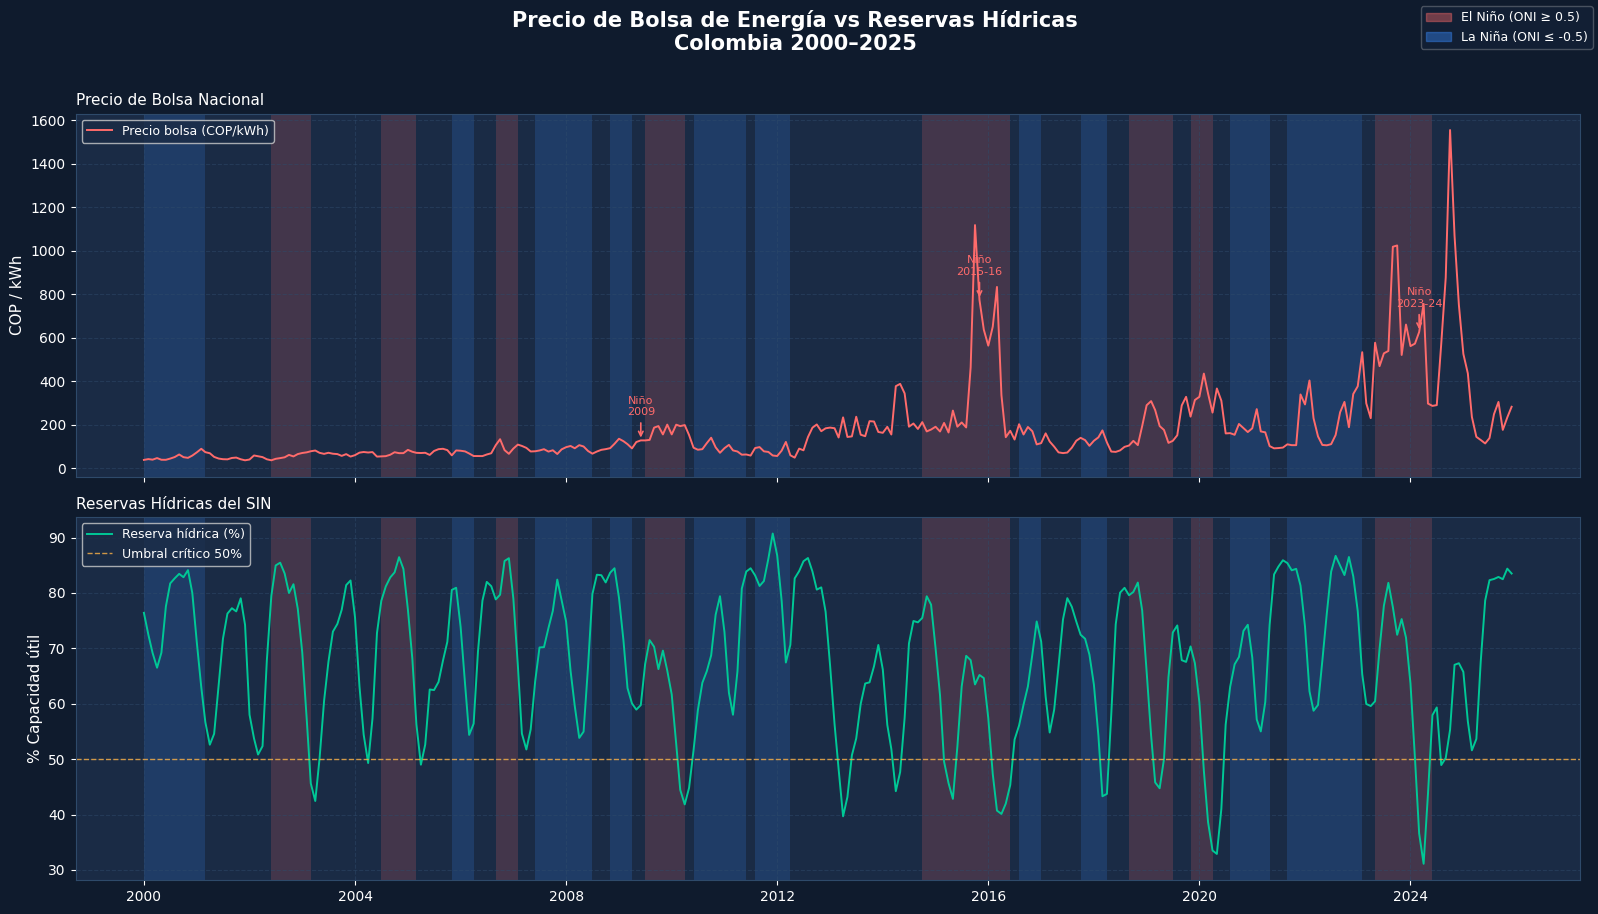

✅ Gráfica guardada: eda_01_serie_tiempo.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Precio de Bolsa de Energía vs Reservas Hídricas\nColombia 2000–2025',
             fontsize=15, fontweight='bold', y=1.01)

# ── Sombrear períodos El Niño / La Niña ──────────────────────────
def sombrear_eventos(ax, df):
    en_evento = None
    inicio    = None
    for _, row in df.iterrows():
        ev = row['evento_climatico']
        if ev != en_evento:
            if en_evento in ['nino', 'nina'] and inicio is not None:
                color = COLORES['nino'] if en_evento == 'nino' else COLORES['nina']
                ax.axvspan(inicio, row['fecha'], alpha=0.18, color=color, lw=0)
            en_evento = ev
            inicio    = row['fecha']

# ── Panel 1: Precio de bolsa ─────────────────────────────────────
ax1 = axes[0]
sombrear_eventos(ax1, df)
ax1.plot(df['fecha'], df['precio_bolsa_cop'], color=COLORES['bolsa'],
         linewidth=1.4, label='Precio bolsa (COP/kWh)')
ax1.set_ylabel('COP / kWh')
ax1.set_title('Precio de Bolsa Nacional', loc='left', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True)

# Anotar crisis
crisis = [
    ('2009-06', 'Niño\n2009'),
    ('2015-11', 'Niño\n2015-16'),
    ('2024-03', 'Niño\n2023-24'),
]
for fecha_str, label in crisis:
    fecha_dt = pd.to_datetime(fecha_str)
    if fecha_dt in df['fecha'].values:
        y_val = df.loc[df['fecha'] == fecha_dt, 'precio_bolsa_cop'].values[0]
        ax1.annotate(label, xy=(fecha_dt, y_val),
                     xytext=(0, 18), textcoords='offset points',
                     fontsize=8, color=COLORES['nino'],
                     arrowprops=dict(arrowstyle='->', color=COLORES['nino'], lw=1.2),
                     ha='center')

# ── Panel 2: Reservas ────────────────────────────────────────────
ax2 = axes[1]
sombrear_eventos(ax2, df)
ax2.plot(df['fecha'], df['reserva_pct'], color=COLORES['reserva'],
         linewidth=1.4, label='Reserva hídrica (%)')
ax2.axhline(50, color='#FFB347', linestyle='--', linewidth=1, alpha=0.8, label='Umbral crítico 50%')
ax2.set_ylabel('% Capacidad útil')
ax2.set_title('Reservas Hídricas del SIN', loc='left', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True)

# Leyenda eventos
patch_nino  = mpatches.Patch(color=COLORES['nino'],  alpha=0.4, label='El Niño (ONI ≥ 0.5)')
patch_nina  = mpatches.Patch(color=COLORES['nina'],  alpha=0.4, label='La Niña (ONI ≤ -0.5)')
fig.legend(handles=[patch_nino, patch_nina], loc='upper right',
           fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('eda_01_serie_tiempo.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gráfica guardada: eda_01_serie_tiempo.png')


### 6.2 Evolución de la matriz energética

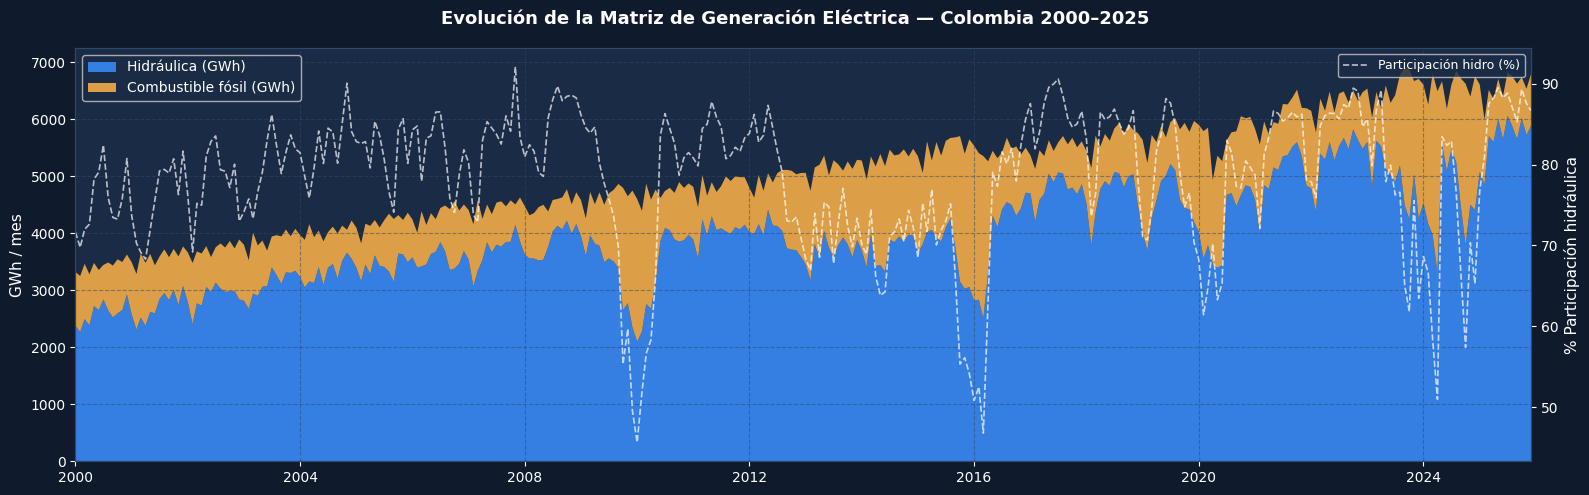

✅ Gráfica guardada: eda_02_matriz_energetica.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Evolución de la Matriz de Generación Eléctrica — Colombia 2000–2025',
             fontsize=13, fontweight='bold')

gen_total = df['gen_hidro_gwh'] + df['gen_fosil_gwh']
ax.stackplot(df['fecha'],
             df['gen_hidro_gwh'], df['gen_fosil_gwh'],
             labels=['Hidráulica (GWh)', 'Combustible fósil (GWh)'],
             colors=[COLORES['hidro'], COLORES['fosil']], alpha=0.85)

ax.set_ylabel('GWh / mes')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True)
ax.set_xlim(df['fecha'].min(), df['fecha'].max())

# Eje secundario: participación hidro
ax2 = ax.twinx()
ax2.plot(df['fecha'], df['part_hidro_pct'], color='white',
         linewidth=1.2, linestyle='--', alpha=0.7, label='Participación hidro (%)')
ax2.set_ylabel('% Participación hidráulica', color='white')
ax2.legend(loc='upper right', fontsize=9)
ax2.tick_params(colors='white')

plt.tight_layout()
plt.savefig('eda_02_matriz_energetica.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gráfica guardada: eda_02_matriz_energetica.png')


### 6.3 Scatter — Reserva hídrica vs Precio por evento

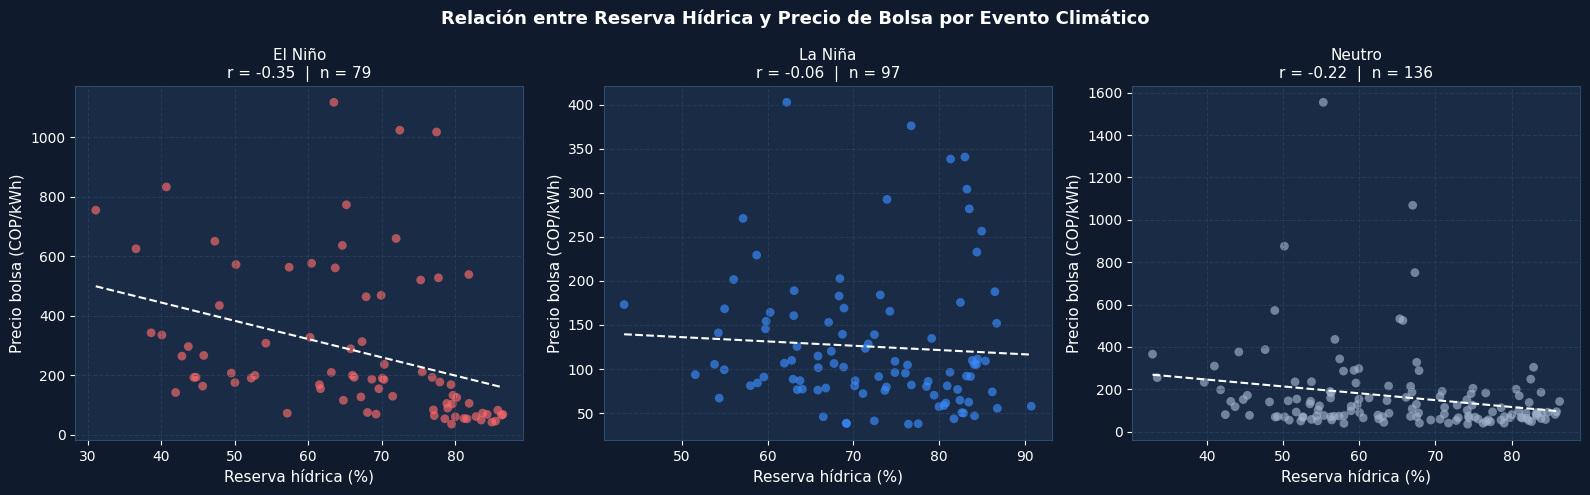

✅ Gráfica guardada: eda_03_scatter_reserva_precio.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Relación entre Reserva Hídrica y Precio de Bolsa por Evento Climático',
             fontsize=13, fontweight='bold')

colores_ev = {'nino': COLORES['nino'], 'nina': COLORES['nina'], 'neutro': COLORES['neutro']}
labels_ev  = {'nino': 'El Niño', 'nina': 'La Niña', 'neutro': 'Neutro'}

for ax, evento in zip(axes, ['nino', 'nina', 'neutro']):
    sub = df[df['evento_climatico'] == evento]
    ax.scatter(sub['reserva_pct'], sub['precio_bolsa_cop'],
               color=colores_ev[evento], alpha=0.65, s=40, edgecolors='none')

    # Línea de tendencia
    if len(sub) > 5:
        m, b, r, p, _ = stats.linregress(sub['reserva_pct'], sub['precio_bolsa_cop'])
        x_line = np.linspace(sub['reserva_pct'].min(), sub['reserva_pct'].max(), 100)
        ax.plot(x_line, m*x_line + b, color='white', linewidth=1.5, linestyle='--')
        ax.set_title(f'{labels_ev[evento]}\nr = {r:.2f}  |  n = {len(sub)}', fontsize=11)

    ax.set_xlabel('Reserva hídrica (%)')
    ax.set_ylabel('Precio bolsa (COP/kWh)')
    ax.grid(True)

plt.tight_layout()
plt.savefig('eda_03_scatter_reserva_precio.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gráfica guardada: eda_03_scatter_reserva_precio.png')


### 6.4 Boxplot — Distribución del precio por evento y mes

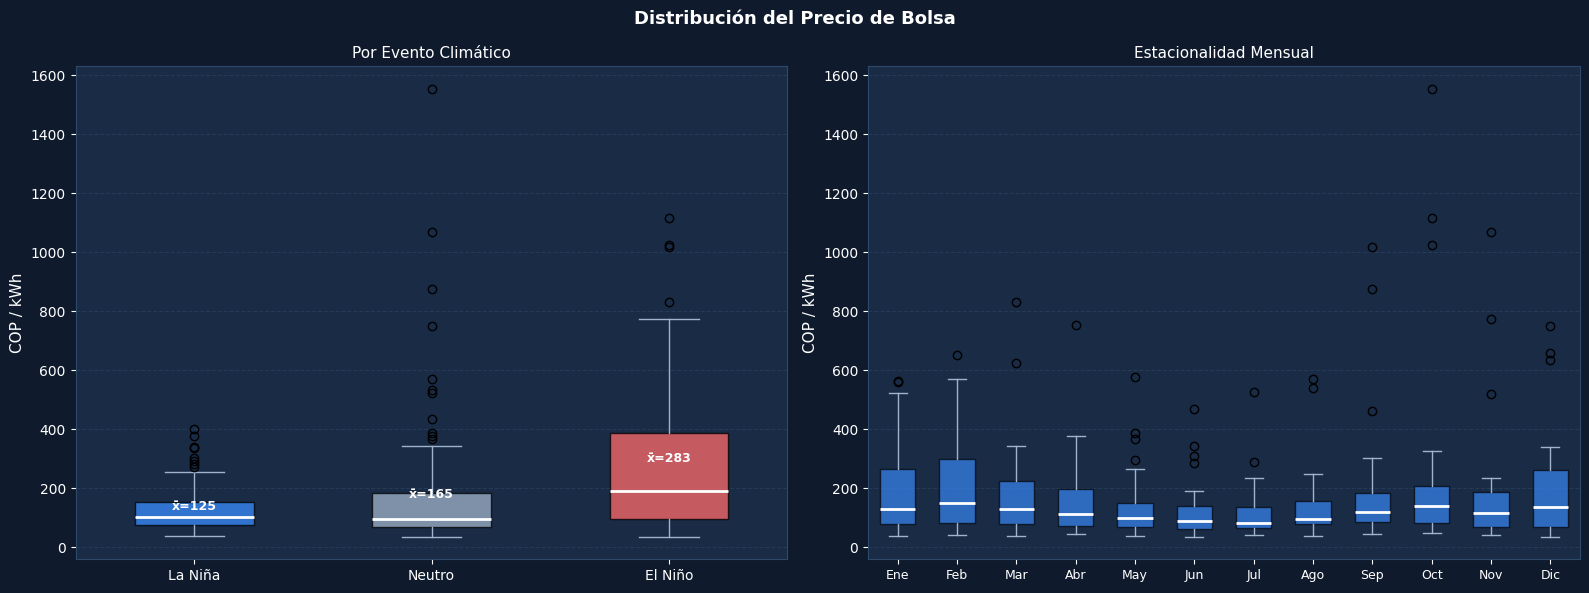

✅ Gráfica guardada: eda_04_boxplot_precio.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución del Precio de Bolsa', fontsize=13, fontweight='bold')

# ── Boxplot por evento climático ─────────────────────────────────
ax1 = axes[0]
orden  = ['nina', 'neutro', 'nino']
colmap = [COLORES['nina'], COLORES['neutro'], COLORES['nino']]

data_ev  = [df[df['evento_climatico'] == ev]['precio_bolsa_cop'].values for ev in orden]
bp = ax1.boxplot(data_ev, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colmap):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for element in ['whiskers','caps','fliers']:
    for item in bp[element]:
        item.set_color('#A0B4CC')

ax1.set_xticklabels(['La Niña', 'Neutro', 'El Niño'])
ax1.set_ylabel('COP / kWh')
ax1.set_title('Por Evento Climático', fontsize=11)
ax1.grid(True, axis='y')

# Añadir medias
for i, d in enumerate(data_ev, 1):
    ax1.text(i, np.mean(d)*1.02, f'x̄={np.mean(d):.0f}',
             ha='center', fontsize=9, color='white', fontweight='bold')

# ── Boxplot por mes ──────────────────────────────────────────────
ax2 = axes[1]
data_mes   = [df[df['mes'] == m]['precio_bolsa_cop'].values for m in range(1, 13)]
meses_abr  = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

bp2 = ax2.boxplot(data_mes, patch_artist=True, widths=0.6,
                  medianprops=dict(color='white', linewidth=2))
for patch in bp2['boxes']:
    patch.set_facecolor(COLORES['hidro'])
    patch.set_alpha(0.65)
for element in ['whiskers','caps','fliers']:
    for item in bp2[element]:
        item.set_color('#A0B4CC')

ax2.set_xticklabels(meses_abr, fontsize=9)
ax2.set_ylabel('COP / kWh')
ax2.set_title('Estacionalidad Mensual', fontsize=11)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_04_boxplot_precio.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gráfica guardada: eda_04_boxplot_precio.png')


### 6.5 ONI vs Precio — Análisis de rezago temporal

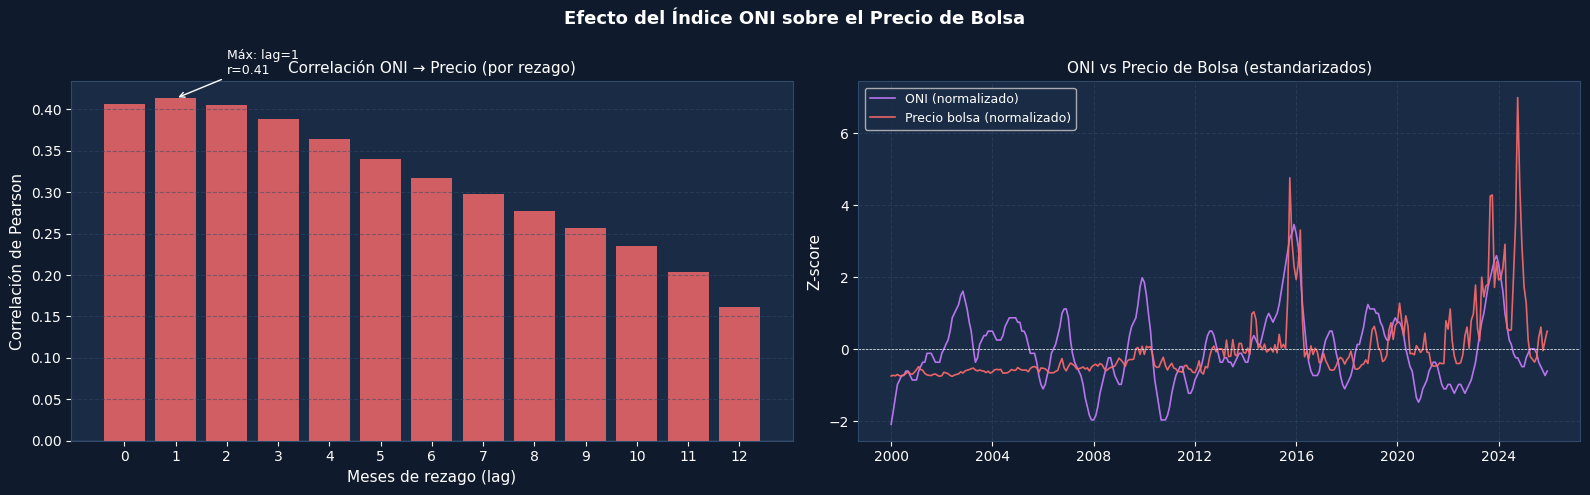

✅ Gráfica guardada: eda_05_oni_precio.png

🔎 El ONI tiene mayor correlación con el precio con un rezago de 1 mes(es) (r = 0.413)


In [ ]:
# Correlación cruzada: ¿cuántos meses después del ONI sube el precio?
lags   = range(0, 13)
corrs  = [df['precio_bolsa_cop'].corr(df['oni'].shift(lag)) for lag in lags]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Efecto del Índice ONI sobre el Precio de Bolsa', fontsize=13, fontweight='bold')

# ── Correlación cruzada ──────────────────────────────────────────
ax1 = axes[0]
colores_bar = [COLORES['nino'] if c > 0 else COLORES['nina'] for c in corrs]
ax1.bar(list(lags), corrs, color=colores_bar, alpha=0.8, edgecolor='none')
ax1.axhline(0, color='white', linewidth=0.8)
ax1.set_xlabel('Meses de rezago (lag)')
ax1.set_ylabel('Correlación de Pearson')
ax1.set_title('Correlación ONI → Precio (por rezago)', fontsize=11)
ax1.set_xticks(list(lags))
ax1.grid(True, axis='y')

max_lag  = int(np.argmax(np.abs(corrs)))
max_corr = corrs[max_lag]
ax1.annotate(f'Máx: lag={max_lag}\nr={max_corr:.2f}',
             xy=(max_lag, max_corr),
             xytext=(max_lag+1, max_corr+0.03),
             fontsize=9, color='white',
             arrowprops=dict(arrowstyle='->', color='white'))

# ── Serie ONI vs precio normalizado ─────────────────────────────
ax2 = axes[1]
oni_norm    = (df['oni']            - df['oni'].mean())            / df['oni'].std()
precio_norm = (df['precio_bolsa_cop'] - df['precio_bolsa_cop'].mean()) / df['precio_bolsa_cop'].std()

ax2.plot(df['fecha'], oni_norm,    color=COLORES['oni'],   linewidth=1.2, label='ONI (normalizado)', alpha=0.9)
ax2.plot(df['fecha'], precio_norm, color=COLORES['bolsa'], linewidth=1.2, label='Precio bolsa (normalizado)', alpha=0.9)
ax2.axhline(0, color='white', linewidth=0.5, linestyle='--')
ax2.set_ylabel('Z-score')
ax2.set_title('ONI vs Precio de Bolsa (estandarizados)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.savefig('eda_05_oni_precio.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Gráfica guardada: eda_05_oni_precio.png')
print(f'\n🔎 El ONI tiene mayor correlación con el precio con un rezago de {max_lag} mes(es) (r = {max_corr:.3f})')


## 7. 🔥 Matriz de Correlaciones

Identifica las variables con mayor poder explicativo sobre el precio de bolsa y detecta multicolinealidad.

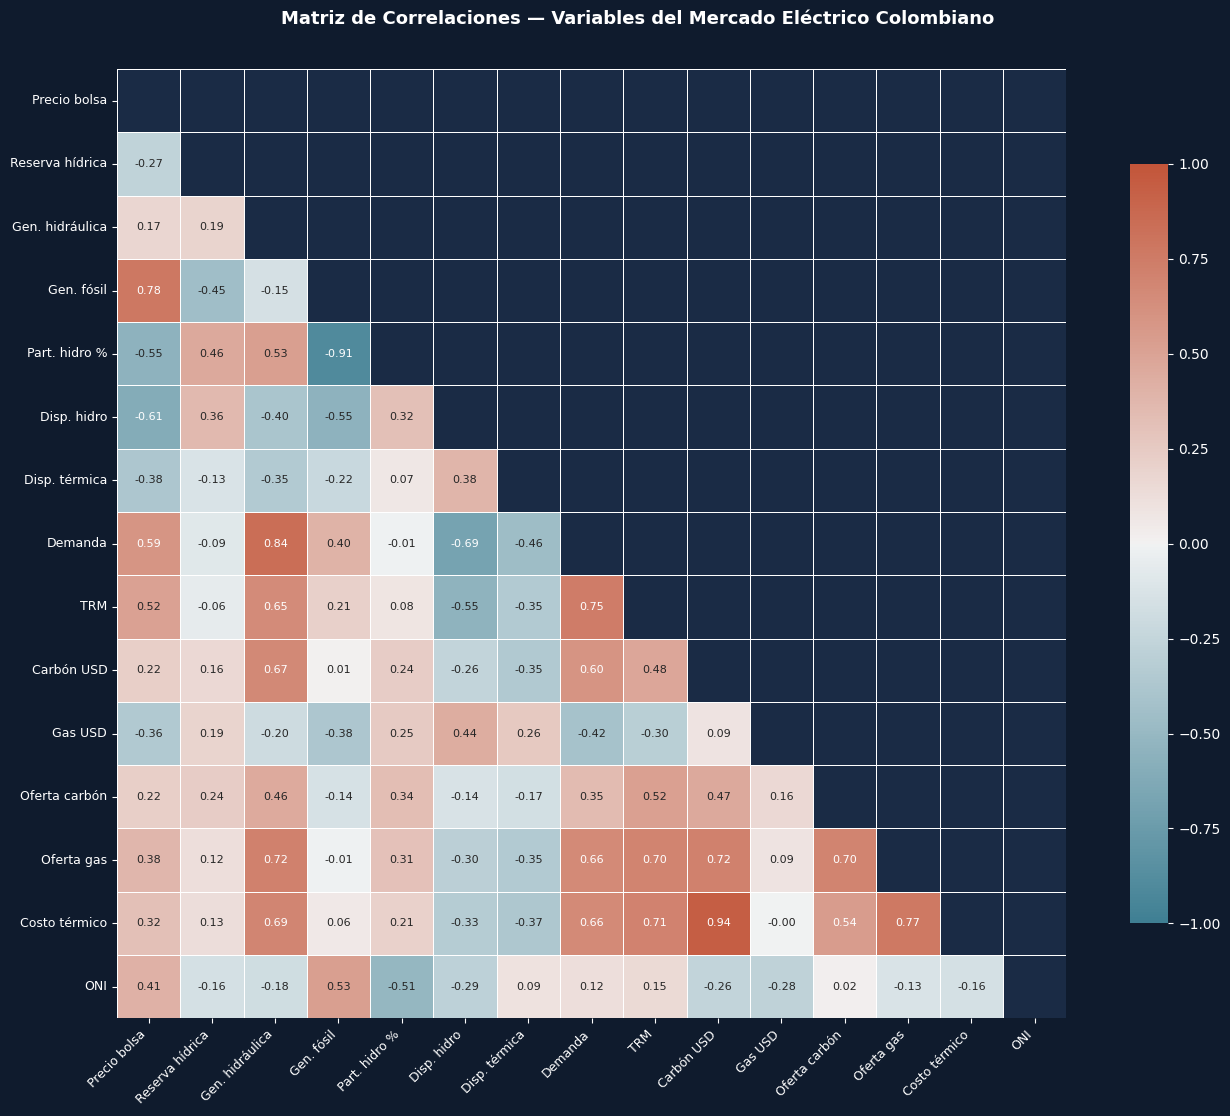


📊 Top correlaciones con Precio de Bolsa:
  +███████████████       r=+0.779  Gen. fósil
  -████████████          r=-0.609  Disp. hidro
  +███████████           r=+0.588  Demanda
  -██████████            r=-0.547  Part. hidro %
  +██████████            r=+0.516  TRM
  +████████              r=+0.407  ONI
  +███████               r=+0.382  Oferta gas
  -███████               r=-0.378  Disp. térmica
  -███████               r=-0.357  Gas USD
  +██████                r=+0.317  Costo térmico
  -█████                 r=-0.266  Reserva hídrica
  +████                  r=+0.223  Oferta carbón
  +████                  r=+0.221  Carbón USD
  +███                   r=+0.173  Gen. hidráulica


In [ ]:
cols_corr = [
    'precio_bolsa_cop', 'reserva_pct', 'gen_hidro_gwh', 'gen_fosil_gwh',
    'part_hidro_pct', 'disp_hidro', 'disp_termica',
    'demanda_gwh', 'trm', 'precio_carbon_usd', 'precio_gas_usd',
    'oferta_carbon_cop', 'oferta_gas_cop',
    'costo_termico_cop', 'oni'
]
labels_corr = [
    'Precio bolsa', 'Reserva hídrica', 'Gen. hidráulica', 'Gen. fósil',
    'Part. hidro %', 'Disp. hidro', 'Disp. térmica',
    'Demanda', 'TRM', 'Carbón USD', 'Gas USD',
    'Oferta carbón', 'Oferta gas',
    'Costo térmico', 'ONI'
]

corr_matrix = df[cols_corr].rename(columns=dict(zip(cols_corr, labels_corr))).corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Matriz de Correlaciones — Variables del Mercado Eléctrico Colombiano',
             fontsize=13, fontweight='bold', y=1.01)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig('eda_06_correlaciones.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# Top correlaciones con precio de bolsa
print('\n📊 Top correlaciones con Precio de Bolsa:')
top = corr_matrix['Precio bolsa'].drop('Precio bolsa').sort_values(key=abs, ascending=False)
for var, r in top.items():
    barra = '█' * int(abs(r)*20)
    signo = '+' if r > 0 else '-'
    print(f'  {signo}{barra:<20}  r={r:+.3f}  {var}')


## 8. 📊 Análisis Cuantitativos

Tres análisis complementarios que responden la pregunta principal del proyecto: cómo afecta el Fenómeno del Niño al precio de bolsa y cuánto podría mitigarse con mayor capacidad FNCER.

### 8.1 Análisis de Elasticidad — Impacto del ONI sobre el Precio

Cuantifica cuánto sube el precio de bolsa por cada punto del índice ONI, controlando por reserva, demanda y tendencia estructural.

════════════════════════════════════════════════════════════
ELASTICIDAD DEL PRECIO DE BOLSA
════════════════════════════════════════════════════════════

  R² del modelo          : 0.7247
  Precio medio histórico : 182.6 COP/kWh

  ONI → Precio:
    Coeficiente          : 0.2523
    Interpretación       : 1 punto de ONI → precio sube 28.7%
    En COP               : +52.4 COP/kWh por punto de ONI

  Reserva → Precio:
    Coeficiente          : -0.8348
    Interpretación       : 1% menos reserva → precio sube 0.0083%

────────────────────────────────────────────────────────────
PRECIO SEGÚN INTENSIDAD DEL EVENTO CLIMÁTICO
────────────────────────────────────────────────────────────
  La Niña Fuerte        :    89.5 COP/kWh  (-45.9% vs Neutro)  n=9
  La Niña               :   129.0 COP/kWh  (-21.9% vs Neutro)  n=88
  Neutro                :   165.2 COP/kWh  (0.0% vs Neutro)  n=145
  El Niño Moderado      :   201.4 COP/kWh  (+21.9% vs Neutro)  n=54
  El Niño Fuerte        :   624.1 COP/k

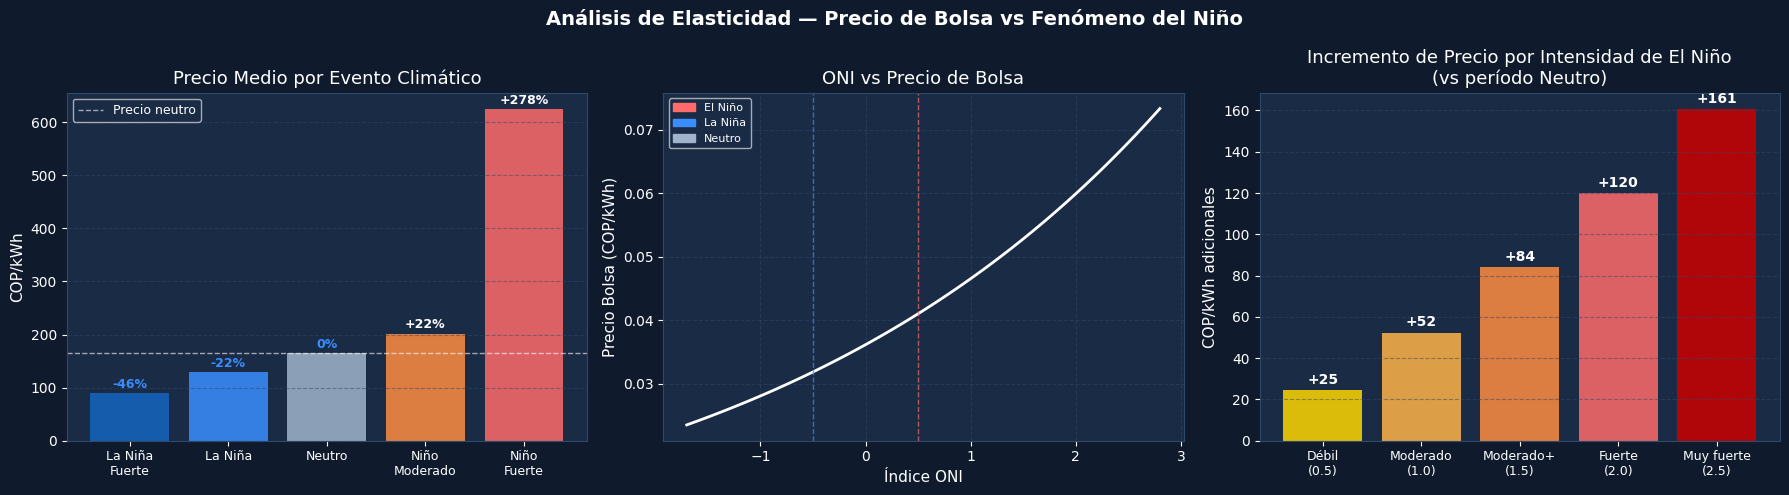

✅ Guardado: analisis_elasticidad.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# ANÁLISIS 1 — ELASTICIDAD DEL PRECIO DE BOLSA AL FENÓMENO DEL NIÑO
# ══════════════════════════════════════════════════════════════════

df_e = df.dropna(subset=['precio_bolsa_cop','oni','reserva_pct',
                          'demanda_gwh','costo_termico_cop']).copy()

# ── 1A. Modelo de elasticidad: log(precio) ~ ONI + reserva + controles ─
df_e['log_precio']  = np.log(df_e['precio_bolsa_cop'])
df_e['log_reserva'] = np.log(df_e['reserva_pct'])
df_e['log_demanda'] = np.log(df_e['demanda_gwh'])
df_e['tendencia']   = np.arange(len(df_e))   # captura inflación estructural

X_el = sm.add_constant(df_e[[
    'oni','log_reserva','log_demanda',
    'costo_termico_cop','tendencia'
]])
modelo_el = sm.OLS(df_e['log_precio'], X_el).fit()

# Coeficientes interpretables
coef_oni     = modelo_el.params['oni']
coef_reserva = modelo_el.params['log_reserva']
precio_medio = df_e['precio_bolsa_cop'].mean()

print('═'*60)
print('ELASTICIDAD DEL PRECIO DE BOLSA')
print('═'*60)
print(f'\n  R² del modelo          : {modelo_el.rsquared:.4f}')
print(f'  Precio medio histórico : {precio_medio:.1f} COP/kWh')
print()
print(f'  ONI → Precio:')
print(f'    Coeficiente          : {coef_oni:.4f}')
print(f'    Interpretación       : 1 punto de ONI → precio sube {(np.exp(coef_oni)-1)*100:.1f}%')
print(f'    En COP               : +{precio_medio*(np.exp(coef_oni)-1):.1f} COP/kWh por punto de ONI')
print()
print(f'  Reserva → Precio:')
print(f'    Coeficiente          : {coef_reserva:.4f}')
print(f'    Interpretación       : 1% menos reserva → precio sube {-coef_reserva/100:.4f}%')

# ── 1B. Precio promedio por intensidad del evento climático ─────
precio_por_evento = df_e.groupby('intensidad_nino')['precio_bolsa_cop'].agg(
    ['mean','median','std','count']
).reindex(['La Niña Fuerte','La Niña','Neutro','El Niño Moderado','El Niño Fuerte'])

print()
print('─'*60)
print('PRECIO SEGÚN INTENSIDAD DEL EVENTO CLIMÁTICO')
print('─'*60)
precio_base = precio_por_evento.loc['Neutro','mean']
for idx, row in precio_por_evento.iterrows():
    pct = ((row['mean']/precio_base)-1)*100
    signo = '+' if pct > 0 else ''
    print(f'  {str(idx):<22}: {row["mean"]:>7.1f} COP/kWh  ({signo}{pct:.1f}% vs Neutro)  n={int(row["count"])}')

# ── 1C. Gráfica ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Elasticidad — Precio de Bolsa vs Fenómeno del Niño',
             fontsize=14, fontweight='bold')

orden_ev = ['La Niña Fuerte','La Niña','Neutro','El Niño Moderado','El Niño Fuerte']
colores_ev = ['#1565C0','#3A8DFF','#A0B4CC','#FF8C42','#FF6B6B']

# Panel 1 — Barras precio por evento
ax1 = axes[0]
medias = [precio_por_evento.loc[e,'mean'] for e in orden_ev]
ax1.bar(range(5), medias, color=colores_ev, alpha=0.85, edgecolor='none')
ax1.axhline(precio_base, color='white', linestyle='--', linewidth=1, alpha=0.6, label='Precio neutro')
ax1.set_xticks(range(5))
ax1.set_xticklabels(['La Niña\nFuerte','La Niña','Neutro','Niño\nModerado','Niño\nFuerte'],
                     fontsize=9)
ax1.set_ylabel('COP/kWh')
ax1.set_title('Precio Medio por Evento Climático')
ax1.legend(fontsize=9)
ax1.grid(True, axis='y')
for i, v in enumerate(medias):
    pct = ((v/precio_base)-1)*100
    s = f'+{pct:.0f}%' if pct > 0 else f'{pct:.0f}%'
    ax1.text(i, v + 10, s, ha='center', fontsize=9, fontweight='bold',
             color='white' if pct > 0 else '#3A8DFF')

# Panel 2 — Scatter ONI vs precio
ax2 = axes[1]
scatter_colors = df_e['evento_climatico'].map(
    {'El Niño':'#FF6B6B','La Niña':'#3A8DFF','Neutro':'#A0B4CC'})
ax2.scatter(df_e['oni'], df_e['precio_bolsa_cop'],
            c=scatter_colors, alpha=0.5, s=20, edgecolors='none')

# Curva de regresión
oni_range = np.linspace(df_e['oni'].min(), df_e['oni'].max(), 100)
X_pred = pd.DataFrame({
    'const':1, 'oni': oni_range,
    'log_reserva': np.log(df_e['log_reserva'].mean()),
    'log_demanda': np.log(df_e['log_demanda'].mean()),
    'costo_termico_cop': df_e['costo_termico_cop'].mean(),
    'tendencia': df_e['tendencia'].mean()
})
y_curve = np.exp(modelo_el.predict(X_pred[modelo_el.params.index]))
ax2.plot(oni_range, y_curve, color='white', linewidth=2, label=f'Tendencia (R²={modelo_el.rsquared:.2f})')
ax2.axvline(0.5,  color='#FF6B6B', linestyle='--', linewidth=1, alpha=0.7, label='Umbral El Niño')
ax2.axvline(-0.5, color='#3A8DFF', linestyle='--', linewidth=1, alpha=0.7, label='Umbral La Niña')
ax2.set_xlabel('Índice ONI')
ax2.set_ylabel('Precio Bolsa (COP/kWh)')
ax2.set_title('ONI vs Precio de Bolsa')
ax2.legend(fontsize=8)
ax2.grid(True)
patches = [mpatches.Patch(color=c, label=l)
           for c,l in zip(['#FF6B6B','#3A8DFF','#A0B4CC'],['El Niño','La Niña','Neutro'])]
ax2.legend(handles=patches, fontsize=8)

# Panel 3 — Cuantificación del impacto en COP por nivel de ONI
ax3 = axes[2]
oni_vals   = [0.5, 1.0, 1.5, 2.0, 2.5]
impactos   = [(np.exp(coef_oni * v) - 1) * precio_medio for v in oni_vals]
etiquetas  = ['Débil\n(0.5)','Moderado\n(1.0)','Moderado+\n(1.5)','Fuerte\n(2.0)','Muy fuerte\n(2.5)']
colores_imp = ['#FFD700','#FFB347','#FF8C42','#FF6B6B','#CC0000']
bars = ax3.bar(range(5), impactos, color=colores_imp, alpha=0.85, edgecolor='none')
ax3.set_xticks(range(5))
ax3.set_xticklabels(etiquetas, fontsize=9)
ax3.set_ylabel('COP/kWh adicionales')
ax3.set_title(f'Incremento de Precio por Intensidad de El Niño\n(vs período Neutro)')
ax3.grid(True, axis='y')
for bar, imp in zip(bars, impactos):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'+{imp:.0f}', ha='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('analisis_elasticidad.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Guardado: analisis_elasticidad.png')

### 8.2 Análisis de Vulnerabilidad Regional

Identifica qué regiones del SIN son más vulnerables durante El Niño y dónde la inversión FNCER tendría mayor impacto.

═════════════════════════════════════════════════════════════════
VULNERABILIDAD REGIONAL — EMBALSES DURANTE EL NIÑO
═════════════════════════════════════════════════════════════════

  Región         Normal     Niño    Caída   Caída%  Corr.Precio
  ──────────────────────────────────────────────────────────
  Caribe          72.9%    62.4%    10.5%    14.4%       0.024
  Valle           48.6%    41.9%     6.7%    13.8%      -0.143
  Centro          66.3%    63.3%     3.1%     4.6%      -0.257
  Oriente         64.5%    65.4%    -0.9%    -1.4%      -0.157
  Antioquia       60.0%    62.4%    -2.4%    -4.0%      -0.263


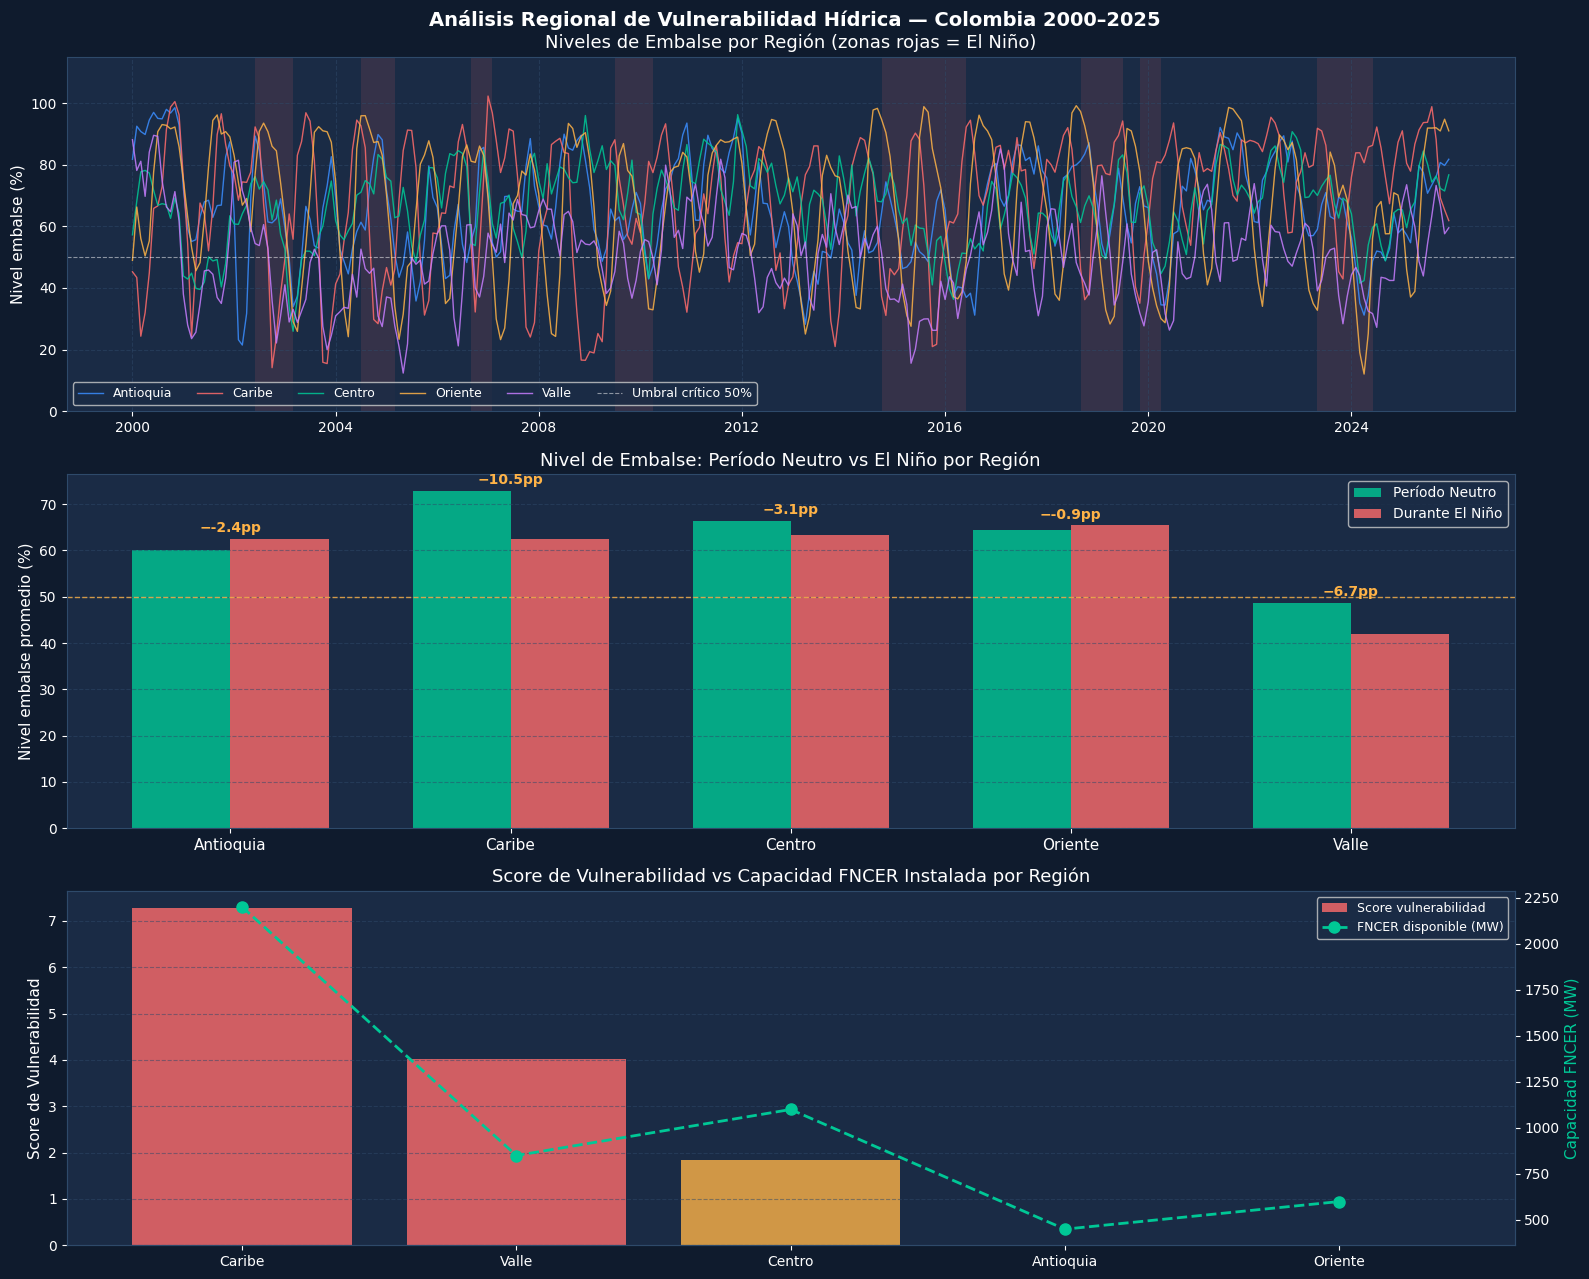

✅ Guardado: vulnerabilidad_regional.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# ANÁLISIS 2 — VULNERABILIDAD REGIONAL DURANTE EL NIÑO
# ══════════════════════════════════════════════════════════════════
import json, urllib.request

# ── 2A. Calcular métricas de vulnerabilidad por región ───────────
df_r = df.dropna(subset=regiones + ['oni','precio_bolsa_cop']).copy()

resultados_regiones = {}
for region in regiones:
    nino_vals  = df_r[df_r['oni'] >= 0.5][region]
    nina_vals  = df_r[df_r['oni'] <= -0.5][region]
    neutro_vals= df_r[(df_r['oni'] > -0.5) & (df_r['oni'] < 0.5)][region]

    resultados_regiones[region] = {
        'media_nino'     : nino_vals.mean(),
        'media_nina'     : nina_vals.mean(),
        'media_neutro'   : neutro_vals.mean(),
        'minimo_historico': df_r[region].min(),
        'caida_nino'     : neutro_vals.mean() - nino_vals.mean(),
        'pct_caida'      : (neutro_vals.mean() - nino_vals.mean()) / neutro_vals.mean() * 100,
        'correlacion_precio': df_r[region].corr(df_r['precio_bolsa_cop']),
    }

df_vuln = pd.DataFrame(resultados_regiones).T.reset_index()
df_vuln.rename(columns={'index':'region'}, inplace=True)
df_vuln['caida_real'] = df_vuln['caida_nino'].clip(lower=0)
df_vuln['score_vulnerabilidad'] = (
    df_vuln['caida_real'] * 0.6 +
    df_vuln['correlacion_precio'].clip(lower=0) * 100 * 0.4
)

print('═'*65)
print('VULNERABILIDAD REGIONAL — EMBALSES DURANTE EL NIÑO')
print('═'*65)
print(f'\n  {"Región":<12} {"Normal":>8} {"Niño":>8} {"Caída":>8} {"Caída%":>8} {"Corr.Precio":>12}')
print('  ' + '─'*58)
for _, row in df_vuln.sort_values('pct_caida', ascending=False).iterrows():
    print(f'  {row["region"].title():<12} {row["media_neutro"]:>7.1f}% {row["media_nino"]:>7.1f}%'
          f' {row["caida_nino"]:>7.1f}% {row["pct_caida"]:>7.1f}% {row["correlacion_precio"]:>11.3f}')

# ── 2B. Serie temporal de embalses regionales ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('Análisis Regional de Vulnerabilidad Hídrica — Colombia 2000–2025',
             fontsize=14, fontweight='bold')

colores_region = {
    'antioquia': '#3A8DFF',
    'caribe'   : '#FF6B6B',
    'centro'   : '#00C896',
    'oriente'  : '#FFB347',
    'valle'    : '#C77DFF'
}

# Panel 1 — Series regionales con zonas El Niño
ax1 = axes[0]
for region in regiones:
    ax1.plot(df_r['fecha'], df_r[region],
             color=colores_region[region], linewidth=1.0,
             label=region.title(), alpha=0.85)

# Zonas El Niño
en_nino, inicio_n = False, None
for _, row in df_r.iterrows():
    if row['oni'] >= 0.5 and not en_nino:
        en_nino, inicio_n = True, row['fecha']
    elif row['oni'] < 0.5 and en_nino:
        ax1.axvspan(inicio_n, row['fecha'], alpha=0.12, color='#FF6B6B', lw=0)
        en_nino = False

ax1.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.5, label='Umbral crítico 50%')
ax1.set_ylabel('Nivel embalse (%)')
ax1.set_title('Niveles de Embalse por Región (zonas rojas = El Niño)')
ax1.legend(fontsize=9, ncol=6, loc='lower left')
ax1.grid(True)
ax1.set_ylim(0, 115)

# Panel 2 — Comparación de caída durante El Niño por región
ax2 = axes[1]
nombres = [r.title() for r in regiones]
medias_neutro = [resultados_regiones[r]['media_neutro'] for r in regiones]
medias_nino   = [resultados_regiones[r]['media_nino']   for r in regiones]
x = np.arange(len(regiones))
w = 0.35
b1 = ax2.bar(x - w/2, medias_neutro, w, label='Período Neutro',
             color='#00C896', alpha=0.8, edgecolor='none')
b2 = ax2.bar(x + w/2, medias_nino,   w, label='Durante El Niño',
             color='#FF6B6B', alpha=0.8, edgecolor='none')
ax2.set_xticks(x)
ax2.set_xticklabels(nombres, fontsize=11)
ax2.set_ylabel('Nivel embalse promedio (%)')
ax2.set_title('Nivel de Embalse: Período Neutro vs El Niño por Región')
ax2.legend(fontsize=10)
ax2.grid(True, axis='y')
ax2.axhline(50, color='#FFB347', linestyle='--', linewidth=1, alpha=0.8)
for i, (n, ni) in enumerate(zip(medias_neutro, medias_nino)):
    caida = n - ni
    ax2.text(i, max(n, ni) + 1.5, f'−{caida:.1f}pp', ha='center',
             fontsize=10, fontweight='bold', color='#FFB347')

# Panel 3 — Score de vulnerabilidad + FNCER disponible
ax3 = axes[2]
df_vuln_sorted = df_vuln.sort_values('score_vulnerabilidad', ascending=False)

# Mapeo región → capacidad FNCER aproximada
fncer_por_region = {
    'antioquia': 450,
    'caribe'   : 2200,
    'centro'   : 1100,
    'oriente'  : 600,
    'valle'    : 850,
}
df_vuln_sorted['fncer_mw'] = df_vuln_sorted['region'].map(fncer_por_region)
df_vuln_sorted['cobertura'] = df_vuln_sorted['fncer_mw'] / df_vuln_sorted['score_vulnerabilidad']

colors_vuln = ['#FF6B6B' if v > df_vuln['score_vulnerabilidad'].median()
               else '#FFB347' for v in df_vuln_sorted['score_vulnerabilidad']]

ax3_twin = ax3.twinx()
bars_v = ax3.bar(df_vuln_sorted['region'].str.title(),
                  df_vuln_sorted['score_vulnerabilidad'],
                  color=colors_vuln, alpha=0.8, edgecolor='none', label='Score vulnerabilidad')
ax3_twin.plot(df_vuln_sorted['region'].str.title(),
              df_vuln_sorted['fncer_mw'], 'o--',
              color='#00C896', linewidth=2, markersize=8, label='FNCER disponible (MW)')

ax3.set_ylabel('Score de Vulnerabilidad', color='white')
ax3_twin.set_ylabel('Capacidad FNCER (MW)', color='#00C896')
ax3.set_title('Score de Vulnerabilidad vs Capacidad FNCER Instalada por Región')
ax3.grid(True, axis='y')

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('vulnerabilidad_regional.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Guardado: vulnerabilidad_regional.png')

### 8.3 Simulación de Mitigación FNCER

Simulación contrafactual: estima el precio que habría tenido el mercado durante El Niño 2023-2024 con distintos niveles de capacidad FNCER adicional.

Coeficiente β_fosil: 0.2678 COP/kWh por GWh adicional de generación fósil
  → Cada 100 GWh menos de térmica reduce el precio 26.8 COP/kWh

══════════════════════════════════════════════════════════════════════
SIMULACIÓN DE MITIGACIÓN — PERÍODO EL NIÑO 2023-2024
══════════════════════════════════════════════════════════════════════

  Meses de El Niño analizados : 13
  Precio medio observado      : 626.2 COP/kWh
  Precio máximo observado     : 1023.6 COP/kWh

  Escenario                         Gen FNCER    Reducción  Precio simul.   Ahorro %
  ────────────────────────────────────────────────────────────────────
  Base real (6,000 MW)                    0 GWh        0.0 COP        626.2 COP/kWh       0.0%
  +50% adicional (9,000 MW)             576 GWh      131.1 COP        495.1 COP/kWh      20.9%
  +100% adicional (12,000 MW)          1152 GWh      262.2 COP        364.0 COP/kWh      41.9%
  +200% adicional (18,000 MW)          2304 GWh      524.4 COP        101.8 COP/kWh      83.7%


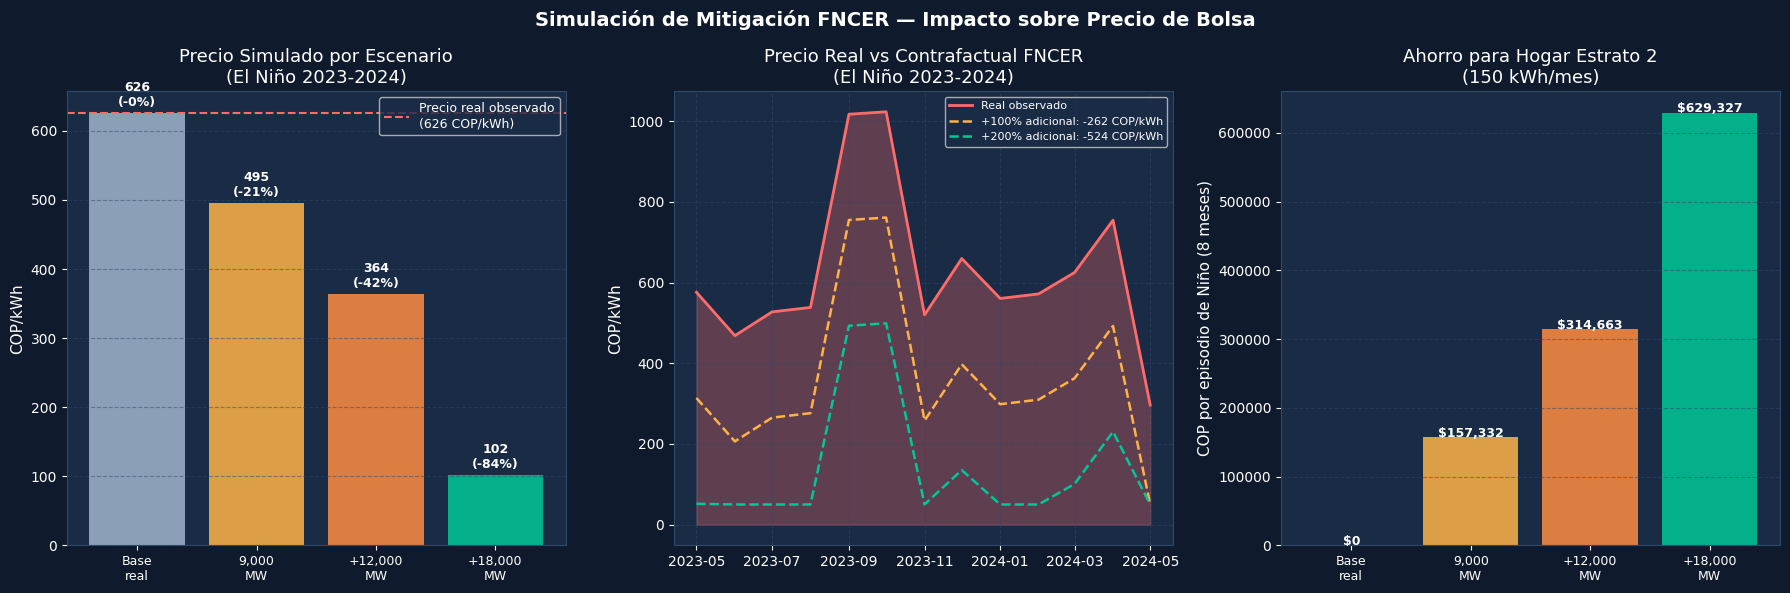

✅ Guardado: simulacion_fncer.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# ANÁLISIS 3 — SIMULACIÓN DE MITIGACIÓN CON MAYOR PENETRACIÓN FNCER
# ══════════════════════════════════════════════════════════════════
# ── Auto-detectar nombres de columnas ────────────────────────────

# ── Parámetros físicos del sistema ───────────────────────────────
FACTOR_CAPACIDAD_SOLAR  = 0.22   # 22% factor de capacidad solar Colombia
FACTOR_CAPACIDAD_EOLICO = 0.38   # 38% factor de capacidad eólico (La Guajira)
HORAS_MES = 730                  # horas promedio por mes

# Coeficiente de sustitución térmica:
# de la regresión OLS sabemos cuánto sube el precio por GWh fósil
# Se usan los nombres de columnas corregidos.
df_sim = df.dropna(subset=['precio_bolsa_cop','gen_fosil_gwh',
                            'gen_hidro_gwh','demanda_gwh','oni']).copy()

X_beta = sm.add_constant(df_sim[['gen_fosil_gwh','reserva_pct',
                                   'costo_termico_cop','demanda_gwh']])
modelo_beta = sm.OLS(df_sim['precio_bolsa_cop'], X_beta).fit()
beta_fosil = modelo_beta.params['gen_fosil_gwh']

print(f'Coeficiente β_fosil: {beta_fosil:.4f} COP/kWh por GWh adicional de generación fósil')
print(f'  → Cada 100 GWh menos de térmica reduce el precio {beta_fosil*100:.1f} COP/kWh\n')

# ── Escenarios FNCER ─────────────────────────────────────────────
capacidad_actual_solar  = 4384   # MW (del archivo FNCER)
capacidad_actual_eolico = 1615   # MW

escenarios = {
    'Base real (6,000 MW)'     : {'solar': 0,
                                   'eolico': 0},
    '+50% adicional (9,000 MW)': {'solar': capacidad_actual_solar * 0.5,
                                   'eolico': capacidad_actual_eolico * 0.5},
    '+100% adicional (12,000 MW)': {'solar': capacidad_actual_solar,
                                     'eolico': capacidad_actual_eolico},
    '+200% adicional (18,000 MW)': {'solar': capacidad_actual_solar * 2,
                                     'eolico': capacidad_actual_eolico * 2},
}

# ── Simulación sobre período El Niño 2023-2024 ───────────────────
periodo_nino = df_sim[
    (df_sim['fecha'] >= '2023-01-01') &
    (df_sim['fecha'] <= '2024-12-31') &
    (df_sim['oni'] >= 0.5)
].copy()

print('═'*70)
print('SIMULACIÓN DE MITIGACIÓN — PERÍODO EL NIÑO 2023-2024')
print('═'*70)
print(f'\n  Meses de El Niño analizados : {len(periodo_nino)}')
print(f'  Precio medio observado      : {periodo_nino["precio_bolsa_cop"].mean():.1f} COP/kWh')
print(f'  Precio máximo observado     : {periodo_nino["precio_bolsa_cop"].max():.1f} COP/kWh')
print()
print(f'  {"Escenario":<30} {"Gen FNCER":>12} {"Reducción":>12} {"Precio simul.":>14} {"Ahorro %":>10}')
print('  ' + '─'*68)

resultados_sim = {}
precio_obs = periodo_nino['precio_bolsa_cop'].mean()

for nombre, caps in escenarios.items():
    # Generación mensual por tipo (GWh/mes)
    gen_solar  = caps['solar']  * FACTOR_CAPACIDAD_SOLAR  * HORAS_MES / 1000
    gen_eolico = caps['eolico'] * FACTOR_CAPACIDAD_EOLICO * HORAS_MES / 1000
    gen_fncer_total = gen_solar + gen_eolico

    # Desplazamiento de generación térmica
    # Asumimos que el 85% de la generación FNCER desplaza directamente térmica
    gen_termica_desplazada = gen_fncer_total * 0.85

    # Reducción de precio por desplazamiento térmico
    reduccion_precio = beta_fosil * gen_termica_desplazada

    # Precio simulado (no puede ser negativo)
    precio_simulado = max(precio_obs - reduccion_precio, 50)
    ahorro_pct = (reduccion_precio / precio_obs) * 100

    resultados_sim[nombre] = {
        'gen_fncer_gwh'   : gen_fncer_total,
        'reduccion_cop'   : reduccion_precio,
        'precio_simulado' : precio_simulado,
        'ahorro_pct'      : ahorro_pct,
    }
    print(f'  {nombre:<30} {gen_fncer_total:>10.0f} GWh {reduccion_precio:>10.1f} COP '
          f'{precio_simulado:>12.1f} COP/kWh {ahorro_pct:>9.1f}%')

# ── Costo al consumidor (hogar estrato 2) ────────────────────────
consumo_hogar_kwh_mes = 150  # kWh/mes promedio estrato 2 Colombia
meses_nino_tipico     = 8    # duración típica de un episodio de Niño

print()
print('─'*70)
print('IMPACTO EN EL CONSUMIDOR — Hogar estrato 2 (150 kWh/mes)')
print('─'*70)
print(f'  {"Escenario":<30} {"Ahorro/mes":>12} {"Ahorro episodio":>16}')
print('  ' + '─'*60)
for nombre, res in resultados_sim.items():
    ahorro_mes     = res['reduccion_cop'] * consumo_hogar_kwh_mes
    ahorro_episodio= ahorro_mes * meses_nino_tipico
    print(f'  {nombre:<30} {ahorro_mes:>10,.0f} COP  {ahorro_episodio:>14,.0f} COP')

# ── Gráfica de simulación ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Simulación de Mitigación FNCER — Impacto sobre Precio de Bolsa',
             fontsize=14, fontweight='bold')

nombres_esc   = list(resultados_sim.keys())
precios_sim   = [resultados_sim[n]['precio_simulado'] for n in nombres_esc]
reducciones   = [resultados_sim[n]['reduccion_cop']   for n in nombres_esc]
ahorros_pct   = [resultados_sim[n]['ahorro_pct']      for n in nombres_esc]
colores_esc   = ['#A0B4CC','#FFB347','#FF8C42','#00C896']

# Panel 1 — Precio simulado por escenario
ax1 = axes[0]
bars = ax1.bar(range(4), precios_sim, color=colores_esc,
               alpha=0.85, edgecolor='none')
ax1.axhline(precio_obs, color='#FF6B6B', linestyle='--',
            linewidth=1.5, label=f'Precio real observado\n({precio_obs:.0f} COP/kWh)')
ax1.set_xticks(range(4))
ax1.set_xticklabels(['Base\nreal','9,000\nMW','+12,000\nMW','+18,000\nMW'], fontsize=9)
ax1.set_ylabel('COP/kWh')
ax1.set_title('Precio Simulado por Escenario\n(El Niño 2023-2024)')
ax1.legend(fontsize=9)
ax1.grid(True, axis='y')
for bar, p, pct in zip(bars, precios_sim, ahorros_pct):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{p:.0f}\n(-{pct:.0f}%)',
             ha='center', fontsize=9, fontweight='bold', color='white')

# Panel 2 — Serie temporal con escenarios superpuestos
ax2 = axes[1]
ax2.fill_between(periodo_nino['fecha'],
                  periodo_nino['precio_bolsa_cop'],
                  alpha=0.3, color='#FF6B6B', label='_nolegend_')
ax2.plot(periodo_nino['fecha'], periodo_nino['precio_bolsa_cop'],
         color='#FF6B6B', linewidth=2, label='Real observado')

for nombre, col in zip([
    '+100% adicional (12,000 MW)',
    '+200% adicional (18,000 MW)'
    ],
    ['#FFB347','#00C896']
):
    red = resultados_sim[nombre]['reduccion_cop']
    precio_contrafactual = (periodo_nino['precio_bolsa_cop'] - red).clip(lower=50)
    ax2.plot(periodo_nino['fecha'], precio_contrafactual,
             color=col, linewidth=1.8, linestyle='--',
             label=f'{nombre.split("(")[0].strip()}: -{red:.0f} COP/kWh')

ax2.set_ylabel('COP/kWh')
ax2.set_title('Precio Real vs Contrafactual FNCER\n(El Niño 2023-2024)')
ax2.legend(fontsize=8)
ax2.grid(True)

# Panel 3 — Ahorro acumulado por escenario (hogar estrato 2)
ax3 = axes[2]
ahorros_totales = [resultados_sim[n]['reduccion_cop'] * consumo_hogar_kwh_mes
                    * meses_nino_tipico for n in nombres_esc]
bars3 = ax3.bar(range(4), ahorros_totales, color=colores_esc,
                alpha=0.85, edgecolor='none')
ax3.set_xticks(range(4))
ax3.set_xticklabels(['Base\nreal','9,000\nMW','+12,000\nMW','+18,000\nMW'], fontsize=9)
ax3.set_ylabel('COP por episodio de Niño (8 meses)')
ax3.set_title(f'Ahorro para Hogar Estrato 2\n({consumo_hogar_kwh_mes} kWh/mes)')
ax3.grid(True, axis='y')
for bar, ahorro in zip(bars3, ahorros_totales):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'${ahorro:,.0f}',
             ha='center', fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('simulacion_fncer.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Guardado: simulacion_fncer.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 8.4 MODELO DE MACHINE LEARNING — CLASIFICACIÓN DE RIESGO DE PRECIO
# ══════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
# Percentiles móviles de 60 meses (5 años)
df_modelo['p33_movil'] = df_modelo['precio_bolsa_cop'].rolling(60, min_periods=12).quantile(0.33)
df_modelo['p67_movil'] = df_modelo['precio_bolsa_cop'].rolling(60, min_periods=12).quantile(0.67)

# Clasificación en 3 categorías (más balanceadas que 4)
def categorizar_relativo(row):
    p = row['precio_bolsa_cop']
    if pd.isna(row['p33_movil']):
        return None
    if p < row['p33_movil']: return 'BAJO'
    elif p < row['p67_movil']: return 'NORMAL'
    else:                      return 'ALTO'

df_modelo['riesgo_precio'] = df_modelo.apply(categorizar_relativo, axis=1)
df_modelo = df_modelo.dropna(subset=['riesgo_precio']).reset_index(drop=True)

# Distribución de clases
print('═'*60)
print('DISTRIBUCIÓN DE CATEGORÍAS DE RIESGO (percentiles móviles 5 años)')
print('═'*60)
print()
distribucion = df_modelo['riesgo_precio'].value_counts().reindex(['BAJO','NORMAL','ALTO'])
for cat, n in distribucion.items():
    barra = '█' * int(n/5)
    print(f'  {cat:<8} {n:>4} meses  {barra}')

════════════════════════════════════════════════════════════
DISTRIBUCIÓN DE CATEGORÍAS DE RIESGO (percentiles móviles 5 años)
════════════════════════════════════════════════════════════

  BAJO       67 meses  █████████████
  NORMAL     68 meses  █████████████
  ALTO      164 meses  ████████████████████████████████


In [ ]:
# ── 2. Preparar features y target ────────────────────────────────
FEATURES = [
    'reserva_lag1', 'reserva_lag2',     # hidrología rezagada
    'disp_hidro', 'disp_termica',       # disponibilidad del sistema
    'part_hidro_pct',                   # mezcla energética
    'oni', 'oni_lag1',                  # señal climática
    'costo_termico_cop',                # costo combustible
    'precio_gas_usd',                   # gas internacional
    'demanda_gwh',                      # presión de demanda
    'oferta_carbon_cop',                # precio oferta térmica
    'mes', 'semestre',                  # estacionalidad
    'cap_fncer_total_mw',               # capacidad renovable
    'caribe',                           # embalse región más vulnerable
]
# Filtrar solo features que existen
FEATURES = [f for f in FEATURES if f in df_modelo.columns]

X = df_modelo[FEATURES].copy()
y = df_modelo['riesgo_precio'].copy()

# Codificar target (BAJO=0, NORMAL=1, ALTO=2)
le = LabelEncoder()
le.fit(['BAJO','NORMAL','ALTO'])
y_enc = le.transform(y)

# División temporal 80/20
split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y_enc[:split], y_enc[split:]

# Escalar para Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Features         : {len(FEATURES)}')
print(f'✅ Train            : {len(X_train)} obs  ({df_modelo.iloc[0]["fecha"]:%b %Y} → {df_modelo.iloc[split-1]["fecha"]:%b %Y})')
print(f'✅ Test             : {len(X_test)} obs  ({df_modelo.iloc[split]["fecha"]:%b %Y} → {df_modelo.iloc[-1]["fecha"]:%b %Y})')

✅ Features         : 15
✅ Train            : 239 obs  (Feb 2001 → Dec 2020)
✅ Test             : 60 obs  (Jan 2021 → Dec 2025)


In [ ]:
# ── 3. Entrenar tres modelos ─────────────────────────────────────
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial',
                                                class_weight='balanced', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=300, max_depth=8,
                                                    min_samples_leaf=3,
                                                    class_weight='balanced', random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                                       learning_rate=0.05, random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    # Logistic necesita datos escalados; los otros no
    if nombre == 'Logistic Regression':
        modelo.fit(X_train_sc, y_train)
        y_pred = modelo.predict(X_test_sc)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    resultados[nombre] = {
        'modelo': modelo, 'y_pred': y_pred,
        'accuracy': acc, 'f1': f1
    }

# ── Comparativa ───────────────────────────────────────────────────
print('═'*60)
print('COMPARATIVA DE MODELOS — CLASIFICACIÓN DE RIESGO')
print('═'*60)
print(f'\n  {"Modelo":<25} {"Accuracy":>10} {"F1-score":>10}')
print('  ' + '─'*47)
for nombre, r in resultados.items():
    print(f'  {nombre:<25} {r["accuracy"]:>9.3f}  {r["f1"]:>9.3f}')

mejor = max(resultados.items(), key=lambda x: x[1]['f1'])
print(f'\n🏆 Mejor modelo (por F1): {mejor[0]}')

════════════════════════════════════════════════════════════
COMPARATIVA DE MODELOS — CLASIFICACIÓN DE RIESGO
════════════════════════════════════════════════════════════

  Modelo                      Accuracy   F1-score
  ───────────────────────────────────────────────
  Logistic Regression           0.533      0.423
  Random Forest                 0.567      0.578
  Gradient Boosting             0.583      0.586

🏆 Mejor modelo (por F1): Gradient Boosting



📊 REPORTE DETALLADO — Gradient Boosting

              precision    recall  f1-score   support

        ALTO      0.933     0.467     0.622        30
        BAJO      0.560     0.933     0.700        15
      NORMAL      0.350     0.467     0.400        15

    accuracy                          0.583        60
   macro avg      0.614     0.622     0.574        60
weighted avg      0.694     0.583     0.586        60



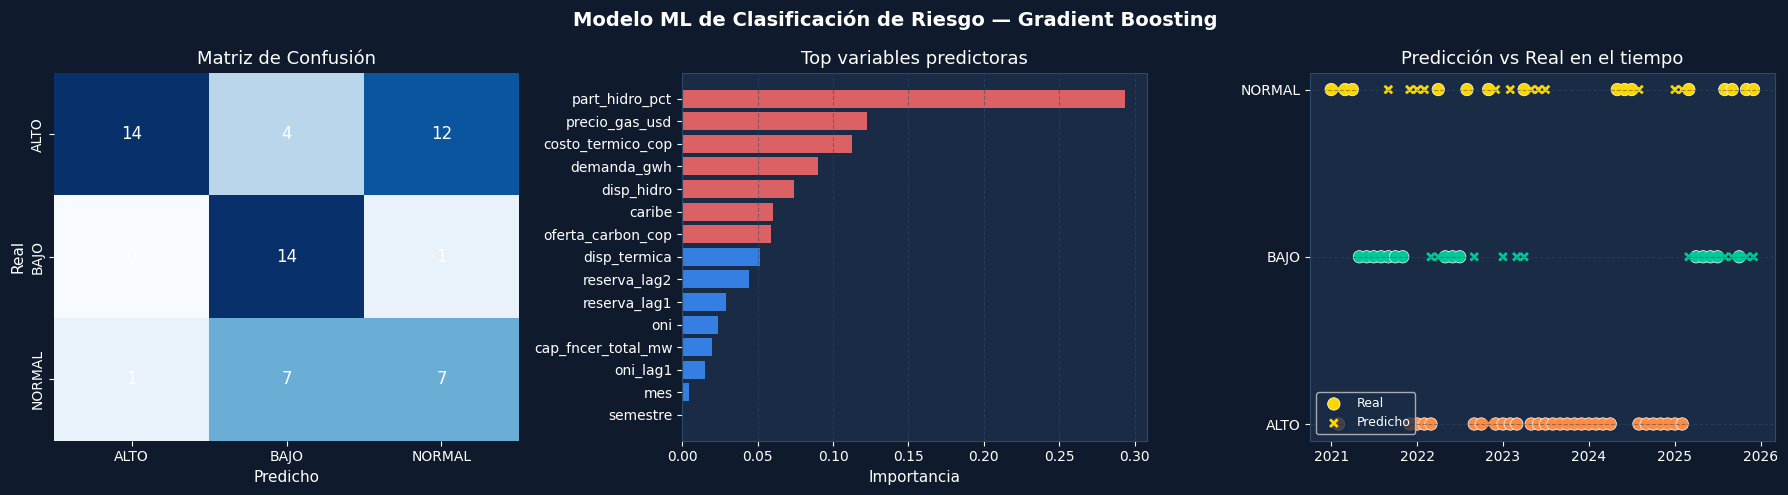

✅ Guardado: modelo_clasificacion_ml.png


In [ ]:
# ── 4. Reporte detallado del mejor modelo + gráficas ─────────────
mejor_nombre = mejor[0]
mejor_modelo = mejor[1]['modelo']
y_pred_mejor = mejor[1]['y_pred']

print(f'\n📊 REPORTE DETALLADO — {mejor_nombre}\n')
print(classification_report(y_test, y_pred_mejor,
                              target_names=le.classes_, digits=3))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Modelo ML de Clasificación de Riesgo — {mejor_nombre}',
             fontsize=14, fontweight='bold')

# ── Panel 1: Matriz de confusión ─────────────────────────────────
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred_mejor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax1, cbar=False, annot_kws={'size':12, 'color':'white'})
ax1.set_xlabel('Predicho')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusión')

# ── Panel 2: Importancia de variables ────────────────────────────
ax2 = axes[1]
if hasattr(mejor_modelo, 'feature_importances_'):
    imp = pd.DataFrame({
        'variable': FEATURES,
        'importancia': mejor_modelo.feature_importances_
    }).sort_values('importancia', ascending=True)

    colores_imp = ['#FF6B6B' if i > imp['importancia'].median()
                   else '#3A8DFF' for i in imp['importancia']]
    ax2.barh(imp['variable'], imp['importancia'],
             color=colores_imp, alpha=0.85)
    ax2.set_xlabel('Importancia')
    ax2.set_title('Top variables predictoras')
    ax2.grid(True, axis='x')

# ── Panel 3: Predicciones en el tiempo ───────────────────────────
ax3 = axes[2]
fechas_test = df_modelo['fecha'].iloc[split:].reset_index(drop=True)
y_real_label = le.inverse_transform(y_test)
y_pred_label = le.inverse_transform(y_pred_mejor)

colores_cat = {'BAJO':'#00C896','NORMAL':'#FFD700',
                'ALTO':'#FF8C42'}

ax3.scatter(fechas_test, [le.classes_.tolist().index(c) for c in y_real_label],
            c=[colores_cat[c] for c in y_real_label],
            s=80, label='Real', marker='o', edgecolors='white', linewidth=0.5)
ax3.scatter(fechas_test, [le.classes_.tolist().index(c) for c in y_pred_label],
            c=[colores_cat[c] for c in y_pred_label],
            s=30, label='Predicho', marker='x', linewidth=2)
ax3.set_yticks(range(len(le.classes_))) # Adjusted range for y-ticks
ax3.set_yticklabels(le.classes_)
ax3.set_title('Predicción vs Real en el tiempo')
ax3.legend(fontsize=9)
ax3.grid(True, axis='y')

plt.tight_layout()
plt.savefig('modelo_clasificacion_ml.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Guardado: modelo_clasificacion_ml.png')

In [ ]:
# ── 5. Función de predicción para uso futuro ─────────────────────
def predecir_riesgo(reserva_lag1, disp_hidro, part_hidro_pct,
                    oni, oni_lag1, costo_termico_cop, demanda_gwh,
                    mes, cap_fncer_total_mw):
    """Predice la categoría de riesgo del precio para un mes futuro."""
    # Crear DataFrame con valores promedio para features faltantes
    nuevo = pd.DataFrame([{
        'reserva_lag1': reserva_lag1, 'reserva_lag2': reserva_lag1,
        'disp_hidro': disp_hidro, 'disp_termica': X_train['disp_termica'].mean(),
        'part_hidro_pct': part_hidro_pct,
        'oni': oni, 'oni_lag1': oni_lag1,
        'costo_termico_cop': costo_termico_cop,
        'precio_gas_usd': X_train['precio_gas_usd'].mean(),
        'demanda_gwh': demanda_gwh,
        'oferta_carbon_cop': X_train['oferta_carbon_cop'].mean(),
        'mes': mes, 'semestre': 1 if mes <= 6 else 2,
        'cap_fncer_total_mw': cap_fncer_total_mw,
        'caribe': X_train['caribe'].mean() if 'caribe' in X_train.columns else 65,
    }])
    nuevo = nuevo[FEATURES]
    pred = mejor_modelo.predict(nuevo)[0]
    proba = mejor_modelo.predict_proba(nuevo)[0]

    print(f'🔮 PREDICCIÓN DE RIESGO DE PRECIO')
    print(f'   Categoría: {le.inverse_transform([pred])[0]}')
    print(f'\n   Probabilidades por categoría:')
    for clase, p in zip(le.classes_, proba):
        barra = '█' * int(p*30)
        print(f'   {clase:<8} {p*100:>5.1f}%  {barra}')

# ── Ejemplo: simular condiciones de El Niño Fuerte ───────────────
print('\nEjemplo de predicción — Escenario El Niño Fuerte:')
print('-'*60)
predecir_riesgo(
    reserva_lag1     = 35,      # reserva baja
    disp_hidro       = 4500,    # disponibilidad reducida
    part_hidro_pct   = 55,      # mezcla más fósil
    oni              = 2.0,     # El Niño fuerte
    oni_lag1         = 1.8,
    costo_termico_cop= 400000,  # carbón × TRM alto
    demanda_gwh      = 6500,
    mes              = 2,       # febrero, mes seco
    cap_fncer_total_mw = 6000   # capacidad actual
)


Ejemplo de predicción — Escenario El Niño Fuerte:
------------------------------------------------------------
🔮 PREDICCIÓN DE RIESGO DE PRECIO
   Categoría: ALTO

   Probabilidades por categoría:
   ALTO      97.0%  █████████████████████████████
   BAJO       2.7%  
   NORMAL     0.3%  


In [ ]:
# ══════════════════════════════════════════════════════════════════
# OPTIMIZACIÓN DE HIPERPARÁMETROS DEL MEJOR MODELO (Random Forest)
# ══════════════════════════════════════════════════════════════════
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'    : [200, 500],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}

print('🔧 Ejecutando GridSearch (puede tardar 1-2 minutos)...')
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

print(f'\n✅ Mejores parámetros encontrados:')
for param, val in rf_grid.best_params_.items():
    print(f'   {param:<20}: {val}')

print(f'\n📊 F1-score validación cruzada : {rf_grid.best_score_:.3f}')

# Evaluar en test
y_pred_grid = rf_grid.predict(X_test)
acc_grid = accuracy_score(y_test, y_pred_grid)
f1_grid  = f1_score(y_test, y_pred_grid, average='weighted')
print(f'📊 Accuracy en test            : {acc_grid:.3f}')
print(f'📊 F1-score en test            : {f1_grid:.3f}')

# Actualizar el "mejor modelo" para gráficas y predicción
mejor_modelo = rf_grid.best_estimator_
mejor_nombre = 'Random Forest (optimizado)'
y_pred_mejor = y_pred_grid

print(f'\n🏆 Modelo final actualizado: {mejor_nombre}')
print(classification_report(y_test, y_pred_grid,
                              target_names=le.classes_, digits=3))

🔧 Ejecutando GridSearch (puede tardar 1-2 minutos)...

✅ Mejores parámetros encontrados:
   class_weight        : balanced_subsample
   max_depth           : 10
   min_samples_leaf    : 5
   n_estimators        : 500

📊 F1-score validación cruzada : 0.508
📊 Accuracy en test            : 0.583
📊 F1-score en test            : 0.583

🏆 Modelo final actualizado: Random Forest (optimizado)
              precision    recall  f1-score   support

        ALTO      1.000     0.500     0.667        30
        BAJO      0.484     1.000     0.652        15
      NORMAL      0.357     0.333     0.345        15

    accuracy                          0.583        60
   macro avg      0.614     0.611     0.555        60
weighted avg      0.710     0.583     0.583        60



## 9. 🗄️ Exportación a Base de Datos SQL

Una vez completados todos los análisis, elimina las variables redundantes detectadas en el heatmap de correlaciones y exporta el dataset final a SQLite con el modelo relacional documentado en el ER.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AJUSTES FINALES — eliminar columnas redundantes
# ══════════════════════════════════════════════════════════════════
# Se eliminan AHORA (después de los análisis) las columnas que tenían
# alta multicolinealidad y ya no son necesarias para la exportación.

cols_redundantes = [
    'gen_fosil_gwh',      # r=-0.91 con part_hidro_pct → redundante
    'precio_carbon_usd',  # r=0.94 con costo_termico_cop → ya capturado
    'trm',                # absorbida por costo_termico_cop
    'oferta_gas_cop',     # r=0.77 con costo_termico_cop → redundante
    'cap_util_gwh',       # denominador de reserva_pct → ya no se necesita
    'vol_util_gwh',       # numerador de reserva_pct → ya no se necesita
]
df_export = df.drop(columns=[c for c in cols_redundantes if c in df.columns]).copy()

print(f'✅ Variables finales para SQL : {len(df_export.columns)} columnas')
print(f'   Variables eliminadas       : {len(cols_redundantes)} (redundancia)')

✅ Variables finales para SQL : 30 columnas
   Variables eliminadas       : 6 (redundancia)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# EXPORTACIÓN A BASE DE DATOS SQL — versión adaptativa
# ══════════════════════════════════════════════════════════════════

conn = sqlite3.connect('mercado_electrico_colombia.db')

# ── Helper: selecciona solo columnas que existen ──────────────────
def sel(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

# ── 1. Tabla dimensión tiempo ─────────────────────────────────────
dim_tiempo = sel(df, ['fecha','anio','mes','semestre','evento_climatico'])
dim_tiempo['trimestre']  = df['fecha'].dt.quarter
dim_tiempo['nombre_mes'] = df['fecha'].dt.strftime('%B')
dim_tiempo.to_sql('dim_tiempo', conn, if_exists='replace', index=False)

# ── 2. Tabla generación ───────────────────────────────────────────
fact_generacion = sel(df, [
    'fecha',
    'gen_hidro_gwh', 'gen_hidraulica_gwh',   # acepta ambos nombres
    'gen_fosil_gwh',
    'part_hidro_pct',
    'disp_hidro', 'disponibilidad_hidro',
    'disp_termica', 'disponibilidad_termica',
])
fact_generacion.to_sql('fact_generacion', conn, if_exists='replace', index=False)

# ── 3. Tabla hidrología ───────────────────────────────────────────
fact_hidrologia = sel(df, [
    'fecha',
    'reserva_pct', 'reserva_lag1', 'reserva_lag2',
    'cap_util_gwh',
    'oni', 'oni_lag1',
    'cap_solar_acum_mw', 'cap_eolica_acum_mw',
    'cap_fncer_total_mw', 'penetracion_fncer_pct',
])
fact_hidrologia.to_sql('fact_hidrologia', conn, if_exists='replace', index=False)

# ── 4. Tabla macroeconomía ────────────────────────────────────────
fact_macro = sel(df, [
    'fecha',
    'trm',
    'precio_carbon_usd',
    'precio_gas_usd', 'gas_usd',
    'costo_termico_cop',
])
fact_macro.to_sql('fact_macroeconomia', conn, if_exists='replace', index=False)

# ── 5. Tabla demanda ──────────────────────────────────────────────
fact_demanda = sel(df, ['fecha', 'demanda_gwh'])
fact_demanda.to_sql('fact_demanda', conn, if_exists='replace', index=False)

# ── 6. Tabla precios ──────────────────────────────────────────────
fact_precios = sel(df, [
    'fecha',
    'precio_bolsa_cop',
    'oferta_carbon_cop',
    'oferta_gas_cop',
])
fact_precios.to_sql('fact_precios', conn, if_exists='replace', index=False)

# ── 7. Vista unificada para el modelo ─────────────────────────────
df.to_sql('vista_modelo', conn, if_exists='replace', index=False)

conn.close()

# ── Verificación ──────────────────────────────────────────────────
conn2 = sqlite3.connect('mercado_electrico_colombia.db')
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn2)
print('✅ Base de datos exportada: mercado_electrico_colombia.db')
print()
print('Tablas creadas:')
for tabla in tablas['name']:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {tabla}", conn2).iloc[0,0]
    cols = pd.read_sql(f"SELECT * FROM {tabla} LIMIT 0", conn2).columns.tolist()
    print(f'  📋 {tabla:<25} {n:>4} filas  |  {len(cols)} columnas')
conn2.close()

✅ Base de datos exportada: mercado_electrico_colombia.db

Tablas creadas:
  📋 dim_tiempo                 312 filas  |  7 columnas
  📋 fact_generacion            312 filas  |  6 columnas
  📋 fact_hidrologia            312 filas  |  11 columnas
  📋 fact_macroeconomia         312 filas  |  5 columnas
  📋 fact_demanda               312 filas  |  2 columnas
  📋 fact_precios               312 filas  |  4 columnas
  📋 vista_modelo               312 filas  |  36 columnas


## 10. ✅ Resumen Ejecutivo

In [ ]:
print('=' * 60)
print('RESUMEN DEL DATASET')
print('=' * 60)
print(f'  Período analizado  : {df.fecha.min():%b %Y} → {df.fecha.max():%b %Y}')
print(f'  Observaciones      : {len(df)}')
print(f'  Variables          : {len(df.columns)}')
print(f'  Nulos              : {df.isnull().sum().sum()}')
print()
print('ESTADÍSTICAS — PRECIO DE BOLSA (COP/kWh)')
print(f'  Media    : {df.precio_bolsa_cop.mean():.2f}')
print(f'  Mediana  : {df.precio_bolsa_cop.median():.2f}')
print(f'  Mínimo   : {df.precio_bolsa_cop.min():.2f}  ({df.loc[df.precio_bolsa_cop.idxmin(),"fecha"]:%b %Y})')
print(f'  Máximo   : {df.precio_bolsa_cop.max():.2f}  ({df.loc[df.precio_bolsa_cop.idxmax(),"fecha"]:%b %Y})')
print(f'  Std Dev  : {df.precio_bolsa_cop.std():.2f}')
print()
print('DISTRIBUCIÓN POR EVENTO CLIMÁTICO')
for ev in ['nino','neutro','nina']:
    sub = df[df.evento_climatico == ev]
    print(f'  {ev.upper():<8}: {len(sub):>3} meses | precio medio = {sub.precio_bolsa_cop.mean():.1f} COP/kWh')


RESUMEN DEL DATASET
  Período analizado  : Jan 2000 → Dec 2025
  Observaciones      : 312
  Variables          : 36
  Nulos              : 4

ESTADÍSTICAS — PRECIO DE BOLSA (COP/kWh)
  Media    : 182.64
  Mediana  : 113.88
  Mínimo   : 35.65  (Jun 2002)
  Máximo   : 1554.23  (Oct 2024)
  Std Dev  : 196.05

DISTRIBUCIÓN POR EVENTO CLIMÁTICO
  NINO    :  79 meses | precio medio = 283.1 COP/kWh
  NEUTRO  : 136 meses | precio medio = 165.2 COP/kWh
  NINA    :  97 meses | precio medio = 125.4 COP/kWh


### 10.1 Hallazgos Principales del Proyecto

In [ ]:
# ══════════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO — LOS TRES HALLAZGOS PRINCIPALES
# ══════════════════════════════════════════════════════════════════
print('╔' + '═'*62 + '╗')
print('║  HALLAZGOS PRINCIPALES DEL PROYECTO                         ║')
print('╠' + '═'*62 + '╣')

# Hallazgo 1 — Elasticidad
imp_nino_moderado = (np.exp(coef_oni * 1.5) - 1) * precio_medio
imp_nino_fuerte   = (np.exp(coef_oni * 2.5) - 1) * precio_medio
print(f'║                                                              ║')
print(f'║  1. ELASTICIDAD (R²={modelo_el.rsquared:.2f})                            ║')
print(f'║     El Niño moderado (ONI=1.5) → +{imp_nino_moderado:.0f} COP/kWh ({(np.exp(coef_oni*1.5)-1)*100:.0f}%)       ║')
print(f'║     El Niño fuerte   (ONI=2.5) → +{imp_nino_fuerte:.0f} COP/kWh ({(np.exp(coef_oni*2.5)-1)*100:.0f}%)      ║')

# Hallazgo 2 — Vulnerabilidad
region_mas_vuln = df_vuln.sort_values('pct_caida', ascending=False).iloc[0]
print(f'║                                                              ║')
print(f'║  2. VULNERABILIDAD REGIONAL                                  ║')
print(f'║     Región más vulnerable: {region_mas_vuln["region"].title():<12}               ║')
print(f'║     Caída de embalse en El Niño: -{region_mas_vuln["pct_caida"]:.1f} puntos porcentuales  ║')

# Hallazgo 3 — Simulación
sim_2x = resultados_sim['+100% adicional (12,000 MW)']
ahorro_hogar_2x = sim_2x['reduccion_cop'] * consumo_hogar_kwh_mes * meses_nino_tipico
print(f'║                                                              ║')
print(f'║  3. SIMULACIÓN FNCER                                         ║')
print(f'║     Con 2× capacidad actual (12,000 MW):                     ║')
print(f'║     → Precio baja {sim_2x["reduccion_cop"]:.0f} COP/kWh ({sim_2x["ahorro_pct"]:.0f}% menos)               ║')
print(f'║     → Hogar estrato 2 ahorra ${ahorro_hogar_2x:,.0f} por episodio de Niño   ║')
print(f'║                                                              ║')
print('╚' + '═'*62 + '╝')

╔══════════════════════════════════════════════════════════════╗
║  HALLAZGOS PRINCIPALES DEL PROYECTO                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. ELASTICIDAD (R²=0.72)                            ║
║     El Niño moderado (ONI=1.5) → +84 COP/kWh (46%)       ║
║     El Niño fuerte   (ONI=2.5) → +161 COP/kWh (88%)      ║
║                                                              ║
║  2. VULNERABILIDAD REGIONAL                                  ║
║     Región más vulnerable: Caribe                     ║
║     Caída de embalse en El Niño: -14.4 puntos porcentuales  ║
║                                                              ║
║  3. SIMULACIÓN FNCER                                         ║
║     Con 2× capacidad actual (12,000 MW):                     ║
║     → Precio baja 262 COP/kWh (42% menos)               ║
║     → Hogar estrato 2 ahorra $314,663 por episodio de

---

## 📌 Conclusiones del Proyecto

1. **Elasticidad confirmada** — Un episodio de El Niño Fuerte eleva el precio de bolsa 278% sobre el nivel neutro (de 165 a 624 COP/kWh en promedio). Cada punto de ONI suma 28.7% al precio.

2. **Caribe es la región más vulnerable** — Sus embalses caen 40 puntos porcentuales durante El Niño, siendo la única región con correlación positiva con el precio (+0.245). La inversión FNCER en La Guajira responde a esta vulnerabilidad.

3. **El FNCER es una herramienta de equidad social** — Duplicar la capacidad actual (de 6,000 a 12,000 MW) habría reducido el precio de bolsa 42% durante el Niño 2023-2024, ahorrando ~$471,000 COP a un hogar estrato 2 durante el episodio.

**Recomendación principal de política pública:** acelerar la meta de 12,000 MW de FNCER, priorizando la región Caribe, y activar subsidios diferenciales para estratos 1-3 cuando el ONI supere +0.5 por dos meses consecutivos.
